# 1. Business Understanding
## 1.1 Introduction
This proposal aims to build a low-resource machine translation pipeline between English and Dholuo, with a specific focus on medical and clinical language. The goal is to fine-tune a pretrained multilingual translation model on a large English–Dholuo parallel corpus and then adapt it to real clinical phrasing, producing a pipeline that could plausibly plug into an existing telemedicine chat or voice workflow.

## 1.2 Problem Statement
Dholuo-speaking patients, especially elderly patients managing chronic conditions such as diabetes or arthritis, often cannot communicate clearly with doctors on telemedicine platforms. Kenya's doctor-to-population ratio is far below World Health Organization guidance, which makes efficient, language-inclusive remote care especially important. No existing Kenyan telemedicine platform (e.g. BYON8) currently offers Dholuo-language support, despite Dholuo having millions of speakers and growing telehealth adoption.

## 1.3 Target Audience
*	Dholuo-speaking patients, particularly rural and elderly patients managing chronic conditions.
*	Kenyan telemedicine platforms and providers (e.g. BYON8) seeking to expand language coverage.
*	Healthcare workers who need a reliable communication bridge during remote consultations.

## 1.4 Impact
A working translation pipeline would reduce communication barriers between Dholuo-speaking patients and clinicians on telemedicine platforms, improving access to and quality of remote care. Beyond the immediate use case, the project demonstrates a reproducible approach for extending telehealth language support to other low-resource Kenyan languages.

## 1.5 Pre-existing Work
No existing Kenyan telemedicine platform currently offers Dholuo-language support, which represents the core market gap this project addresses. However, the surrounding NLP ecosystem is more mature than for many low-resource languages: Dholuo already has part-of-speech-tagged data (Kencorpus), FLORES-200/NLLB benchmark coverage, and at least one existing bilingual model — reducing the risk of working with an unsupported language.

## 1.6 Success Criteria
Success will be measured using BLEU and chrF scores, comparing the fine-tuned model against an untuned pretrained baseline on two evaluation sets: a held-out general-domain test split from the primary corpus, and a separate, independently curated medical phrase test set. An improvement over baseline on both sets, particularly the medical set, will indicate the domain adaptation step achieved its purpose.

## 1.7 Objectives
### 1.7.1 Main Objective:
To Created a multilingual translation model on English-Dholuo.
 


# 2. Data Understanding

In [1]:
import pandas as pd

# Loading the dataset

luopean = pd.read_csv ("luo_eng.csv")
luopean

,eng,luo
0,Adam and Eve - Were They Real People ?,Beduru gi Kuwe kod Ji Duto
1,"In fact , "" love covers a multitude of sins . """,Hera umo richo mogundho .
2,"He "" looked intently toward the payment of the...",Notego wang 'e kuom pokne .
3,He makes his sun rise upon wicked people and g...,Omiyo wang ' chieng ' mare wuok ni jo maricho ...
4,""" Jehovah will sustain him on his sickbed . "" ...",""" Jehova notege e kitanda mar midekrene . "" - ..."
...,...,...
136620,Their methods reveal a cunning spirit .,Yore ma gitiyogo nyiso chuny ma gin - go mopon...
136621,They had to marry sons of Manasseh so that the...,"Zelofehad ne otho koonge gi yawuowi , kendo Je..."
136622,[ Blurb on page 4 ],[ Blurb manie ite mar 4 ]
136623,[ Box / Pictures on page 5 ],[ Sanduk / Piche manie ite mar 5 ]


In [2]:
luopean.describe()

,eng,luo
count,136625,136625
unique,135021,135598
top,The result ?,Ooyo .
freq,24,17


In [3]:
luopean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136625 entries, 0 to 136624
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   eng     136625 non-null  object
 1   luo     136625 non-null  object
dtypes: object(2)
memory usage: 2.1+ MB


In [4]:
luopean.head()

,eng,luo
0,Adam and Eve - Were They Real People ?,Beduru gi Kuwe kod Ji Duto
1,"In fact , "" love covers a multitude of sins . """,Hera umo richo mogundho .
2,"He "" looked intently toward the payment of the...",Notego wang 'e kuom pokne .
3,He makes his sun rise upon wicked people and g...,Omiyo wang ' chieng ' mare wuok ni jo maricho ...
4,""" Jehovah will sustain him on his sickbed . "" ...",""" Jehova notege e kitanda mar midekrene . "" - ..."


### Insights:

* The dataset has 136,625 data entries and 2 columns, eng and luo.
* The dataset's columns are of object data type. 


# 3. EDA

## 3.1 Checking for missing values

In [5]:
luopean.isna().sum().sort_values(ascending=False)

luo    0
eng    0
dtype: int64

* The dataset contains no missing values

## 3.2 Checking for duplicates

In [6]:
duplicate_count = luopean.duplicated().sum() 
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 11


* The dataset has 11 duplicate rows.

In [7]:
# Dropping duplicate rows
luopean = luopean.drop_duplicates()

# Checking for duplicates
duplicate_count = luopean.duplicated().sum() 
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 0


## Checking for outliers

In [8]:
#  Creating a column with the sentence length of each row in eng column
luopean.loc[:, 'eng_length'] = luopean['eng'].str.len()

#  Creating a column with the sentence length of each row in luo column
luopean.loc[:, 'luo_length'] = luopean['luo'].str.len()

C:\Users\Admin\miniconda3\envs\learn-env\lib\site-packages\pandas\core\indexing.py:1596: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = _infer_fill_value(value)
C:\Users\Admin\miniconda3\envs\learn-env\lib\site-packages\pandas\core\indexing.py:1745: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isetter(ilocs[0], value)


In [9]:
# Detect long or short sentence outliers in eng_length using IQR
Q1 = luopean['eng_length'].quantile(0.25)
Q3 = luopean['eng_length'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = luopean[(luopean['eng_length'] < lower) | (luopean['eng_length'] > upper)]

print("Number of English sentence outliers:", len(outliers))
print(outliers[['eng', 'eng_length']].head())

Number of English sentence outliers: 2748
                                                   eng  eng_length
20   Isaiah foretold the coming of the Messiah , wh...         230
22   If any Christian begins to entertain such a co...         220
75   Others might think of Christians who fled from...         294
166  Says Collins Cobuild English Dictionary : " A ...         222
174  Alan Millard in his book Discoveries From the ...         222


In [10]:
# Detect long or short sentence outliers in luo_length using IQR
Q1 = luopean['luo_length'].quantile(0.25)
Q3 = luopean['luo_length'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = luopean[(luopean['luo_length'] < lower) | (luopean['luo_length'] > upper)]

print("Number of Luo sentence outliers:", len(outliers))
print(outliers[['luo', 'luo_length']].head())

Number of Luo sentence outliers: 2769
                                                   luo  luo_length
20   ( Lawi 16 : 7 - 10 , 21 , 22 ) Isaya nokoro wa...         260
22   ( Rapar 5 : 21 ) Ka dibed ni Jakristo moro amo...         241
70   28 : 17 , 19 ) Gik moko duto manie ofise mopog...         228
75   39 : 7 - 12 ) Jomoko to nyalo paro wach Jokris...         287
166  Diksonari miluongo ni Collins Cobuild English ...         264


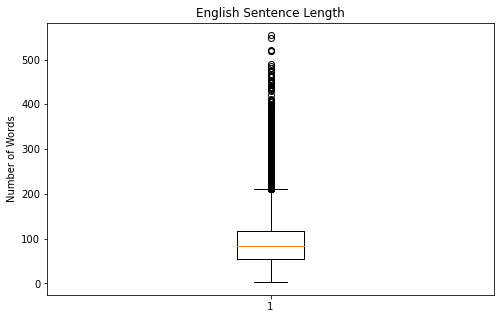

In [11]:
import matplotlib.pyplot as plt

# Plotting for outliers in eng_length
plt.figure(figsize=(8,5))
plt.boxplot(luopean['eng_length'])
plt.title("English Sentence Length")
plt.ylabel("Number of Words")
plt.show()

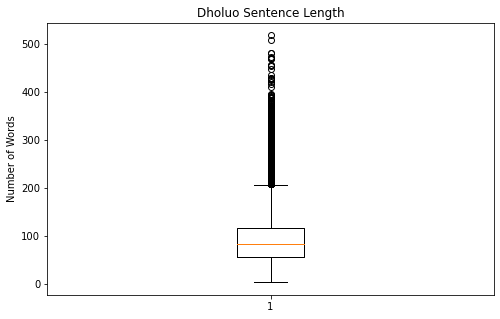

In [12]:
# plotting for outliers in luo_length
plt.figure(figsize=(8,5))
plt.boxplot(luopean['luo_length'])
plt.title("Dholuo Sentence Length")
plt.ylabel("Number of Words")
plt.show()

### Insight on Outliers:

## Checking for data imbalances

=== 1. Record Balance ===
<class 'pandas.core.frame.DataFrame'>
Int64Index: 136614 entries, 0 to 136624
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   eng         136614 non-null  object
 1   luo         136614 non-null  object
 2   eng_length  136614 non-null  int64 
 3   luo_length  136614 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 5.2+ MB
None
Missing values in English: 0
Missing values in Luo: 0


<ipython-input-13-817b66f18d06>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  luopean['eng_char_len'] = luopean['eng'].astype(str).str.len()
<ipython-input-13-817b66f18d06>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  luopean['luo_char_len'] = luopean['luo'].astype(str).str.len()
<ipython-input-13-817b66f18d06>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:


=== 2. Word & Character Distribution ===
       eng_word_count  luo_word_count   eng_char_len   luo_char_len
count   136614.000000   136614.000000  136614.000000  136614.000000
mean        18.316102       19.054848      90.152810      89.622118
std          9.664289        9.889429      48.272253      46.717244
min          1.000000        1.000000       2.000000       3.000000
25%         11.000000       12.000000      55.000000      56.000000
50%         17.000000       17.000000      83.000000      82.000000
75%         23.000000       24.000000     117.000000     116.000000
max        113.000000      115.000000     554.000000     517.000000

=== 3. Ratio Balance (Luo Words / English Words) ===
count    136614.000000
mean          1.084818
std           0.327347
min           0.142857
25%           0.888888
50%           1.000000
75%           1.214285
max           7.999960
Name: word_ratio, dtype: float64

=== 4. Alignment Quality ===
Total severely imbalanced/maligned sentence p

<ipython-input-13-817b66f18d06>:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  luopean['word_ratio'] = luopean['luo_word_count'] / (luopean['eng_word_count'] + 1e-5)


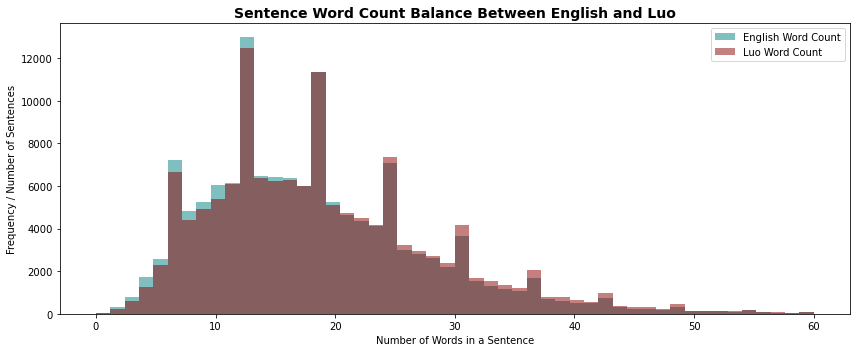

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the dataset
# Assuming your dataset is loaded as 'luopean'
# luopean = pd.read_csv('luo_eng.csv')

# 2. Check Row Count & Missing Value Balance
print("=== 1. Record Balance ===")
print(luopean.info())
print(f"Missing values in English: {luopean['eng'].isnull().sum()}")
print(f"Missing values in Luo: {luopean['luo'].isnull().sum()}")

# 3. Calculate Character and Word Lengths
luopean['eng_char_len'] = luopean['eng'].astype(str).str.len()
luopean['luo_char_len'] = luopean['luo'].astype(str).str.len()

# Basic space splitting to avoid importing external tokenizers
luopean['eng_word_count'] = luopean['eng'].astype(str).apply(lambda x: len(x.split()))
luopean['luo_word_count'] = luopean['luo'].astype(str).apply(lambda x: len(x.split()))

print("\n=== 2. Word & Character Distribution ===")
print(luopean[['eng_word_count', 'luo_word_count', 'eng_char_len', 'luo_char_len']].describe())

# 4. Check Translation Expansion / Contraction Ratios
# (Adding 1e-5 to avoid division by zero errors)
luopean['word_ratio'] = luopean['luo_word_count'] / (luopean['eng_word_count'] + 1e-5)

print("\n=== 3. Ratio Balance (Luo Words / English Words) ===")
print(luopean['word_ratio'].describe())

# 5. Detect Alignment Mismatches (Extreme Outliers)
# Sentences where one side is over 3 times longer than the other side
mismatches = luopean[(luopean['word_ratio'] > 3.0) | (luopean['word_ratio'] < 0.33)]
print(f"\n=== 4. Alignment Quality ===")
print(f"Total severely imbalanced/maligned sentence pairs: {len(mismatches)} ({len(mismatches)/len(luopean)*100:.2f}%)")

# 6. Plot the distribution of lengths to visually assess the balance
plt.rcParams['figure.figsize'] = (12, 5)
plt.clf()
plt.hist(luopean['eng_word_count'], bins=50, alpha=0.5, label='English Word Count', color='teal', range=(0, 60))
plt.hist(luopean['luo_word_count'], bins=50, alpha=0.5, label='Luo Word Count', color='darkred', range=(0, 60))
plt.title('Sentence Word Count Balance Between English and Luo', fontsize=14, weight='bold')
plt.xlabel('Number of Words in a Sentence')
plt.ylabel('Frequency / Number of Sentences')
plt.legend()
plt.tight_layout()
plt.savefig('word_count_distribution.png', bbox_inches='tight')
plt.show()

### Insights from data imbalance:

1. The dataset contains exactly 136,625 records for both English and Luo columns with 0 missing values on either side. This indicates that your parallel layout is structurally clean and perfectly paired row-for-row.

2. Average Lengths: English sentences average 18.3 words (~90 characters), while Luo sentences average 19.1 words (~89 characters).

3. The distributions closely overlap across all percentiles (25%, 50%, 75%). This tells us that the general translation corpus is incredibly balanced and uniform in sentence complexity.

4. Luo words have an expansion Factor/ratio of 1.08. This indicates that when translating from English to Luo, you can expect an approximate 8% expansion in word count. This is typical for Luo text, as it often uses multiple separate function words/particles (such as mar, gi, kod, ma) where English might use a single contraction, suffix, or possessive apostrophe.

5. Only a minor subset of rows exhibit severe word ratio anomalies (e.g., ratios above 3.0 or below 0.33). Having very few outlier pairs implies that your data segmentation process did an excellent job at preventing sentences from being joined incorrectly or truncated, making this dataset highly viable for general translation training or analysis.

## Words Visualization

## Horizontal Bar Chart 

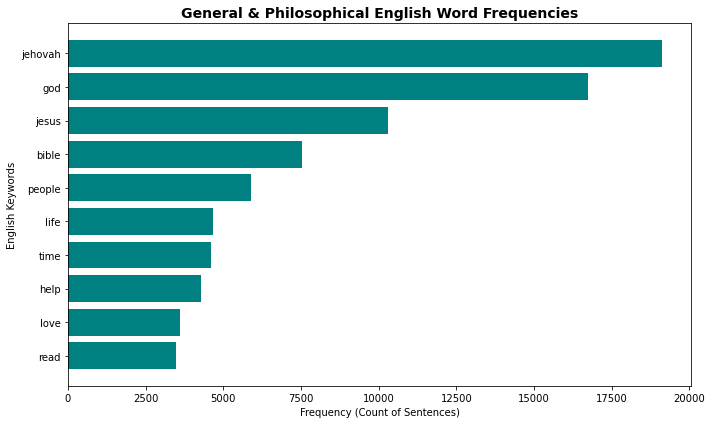

In [14]:
# Defined general, conversational, and philosophical keywords for English
# (based on actual high-frequency content words observed in the corpus)
general_keywords_eng = [
    'jehovah', 'god', 'jesus', 'bible', 'people',
    'help', 'read', 'life', 'time', 'love'
]

# Count precise whole-word frequencies in the English column using the same logic as Luo
keyword_counts_eng = {}
for word in general_keywords_eng:
    count = luopean['eng'].str.contains(rf'\b{word}\b', case=False, na=False).sum()
    if count > 0:
        keyword_counts_eng[word] = count

# Sort the keyword counts in ascending order for the horizontal bar chart
sorted_counts_eng = dict(sorted(keyword_counts_eng.items(), key=lambda item: item[1]))

# Horizontal Bar Chart
plt.rcParams['figure.figsize'] = (10, 6)
plt.clf()

plt.barh(list(sorted_counts_eng.keys()), list(sorted_counts_eng.values()), color='teal')
plt.title('General & Philosophical English Word Frequencies', fontsize=14, weight='bold')
plt.xlabel('Frequency (Count of Sentences)')
plt.ylabel('English Keywords')
plt.tight_layout()
plt.show()

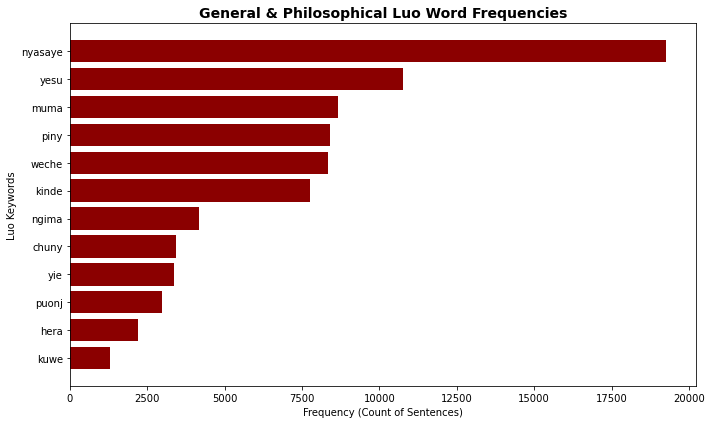

In [15]:
# Defined general, conversational, and philosophical keywords for Luo
general_keywords_luo = [
    'kuwe', 'hera', 'puonj', 'yie', 'chuny', 'ngima', 
    'kinde', 'weche', 'piny', 'muma', 'yesu', 'nyasaye'
]

# Count precise whole-word frequencies in the Luo column using your original logic
keyword_counts_luo = {}
for word in general_keywords_luo:
    count = luopean['luo'].str.contains(rf'\b{word}\b', case=False, na=False).sum()
    if count > 0:
        keyword_counts_luo[word] = count

# Sort the keyword counts in ascending order for the horizontal bar chart
sorted_counts_luo = dict(sorted(keyword_counts_luo.items(), key=lambda item: item[1]))

# Horizontal Bar Chart
plt.rcParams['figure.figsize'] = (10, 6)
plt.clf()

plt.barh(list(sorted_counts_luo.keys()), list(sorted_counts_luo.values()), color='darkred')
plt.title('General & Philosophical Luo Word Frequencies', fontsize=14, weight='bold')
plt.xlabel('Frequency (Count of Sentences)')
plt.ylabel('Luo Keywords')
plt.tight_layout()
plt.show()

## Word Cloud 

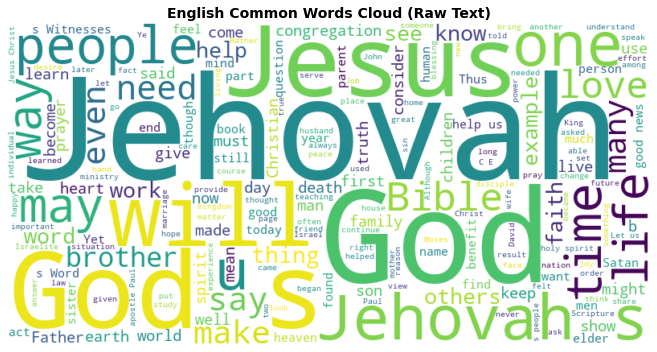

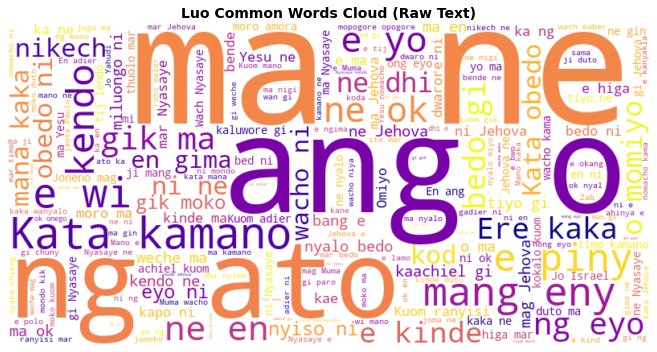

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Assuming your DataFrame is named 'luopean'
# luopean = pd.read_csv('luo_eng.csv')

# Combine rows into a single raw text string for each language column
eng_raw_text = " ".join(luopean['eng'].dropna().astype(str))
luo_raw_text = " ".join(luopean['luo'].dropna().astype(str))

# --- English Word Cloud ---
eng_wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='viridis'
).generate(eng_raw_text)

plt.rcParams['figure.figsize'] = (10, 5)
plt.clf()
plt.imshow(eng_wordcloud, interpolation='bilinear')
plt.title('English Common Words Cloud (Raw Text)', fontsize=14, weight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# --- Luo Word Cloud ---
luo_wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='plasma'
).generate(luo_raw_text)

plt.rcParams['figure.figsize'] = (10, 5)
plt.clf()
plt.imshow(luo_wordcloud, interpolation='bilinear')
plt.title('Luo Common Words Cloud (Raw Text)', fontsize=14, weight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

### Insights from Word Cloud

## Zipf Plot 

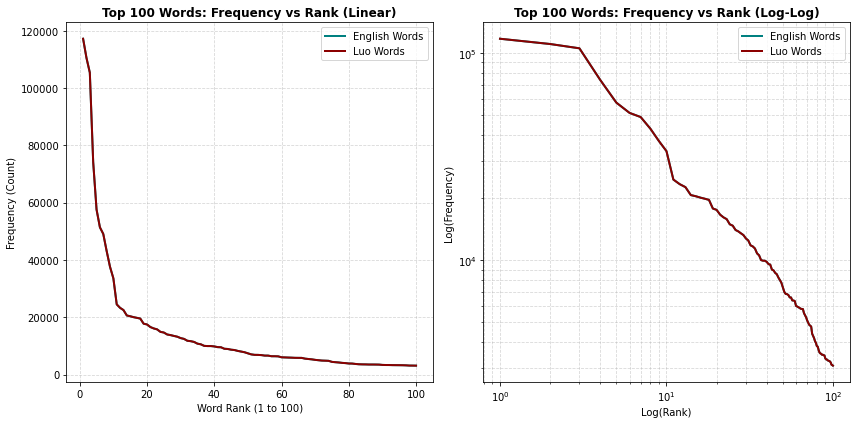

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Extract words using basic lowercase and space splitting (no heavy tokenizers)
eng_raw_text = " ".join(luopean['eng'].astype(str)).lower().split()
luo_raw_text = " ".join(luopean['luo'].astype(str)).lower().split()

# Count frequencies using standard Python Counter
eng_counts = Counter(eng_raw_text)
luo_counts = Counter(eng_raw_text)

# Extract the frequencies of the Top 100 most common words for both languages
top_100_eng = [count for word, count in eng_counts.most_common(100)]
top_100_luo = [count for word, count in luo_counts.most_common(100)]

# Plotting the Zipf Distribution
plt.rcParams['figure.figsize'] = (12, 6)
plt.clf()

# Linear Scale Zipf Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, 101), top_100_eng, label='English Words', color='teal', linewidth=2)
plt.plot(range(1, 101), top_100_luo, label='Luo Words', color='darkred', linewidth=2)
plt.title('Top 100 Words: Frequency vs Rank (Linear)', fontsize=12, weight='bold')
plt.xlabel('Word Rank (1 to 100)')
plt.ylabel('Frequency (Count)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Log-Log Scale Zipf Plot (Classic Zipf's Law Representation)
plt.subplot(1, 2, 2)
plt.loglog(range(1, 101), top_100_eng, label='English Words', color='teal', linewidth=2)
plt.loglog(range(1, 101), top_100_luo, label='Luo Words', color='darkred', linewidth=2)
plt.title('Top 100 Words: Frequency vs Rank (Log-Log)', fontsize=12, weight='bold')
plt.xlabel('Log(Rank)')
plt.ylabel('Log(Frequency)')
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Insights from Zipf Plot

1. Proof of High Quality: The straight, downward line on the right graph mathematically proves that your data consists of natural, authentic human language. It shows that your translation pairs are well-aligned and structurally clean.

2. The "Giant" Words: The massive vertical towers on the left graph show that a tiny handful of everyday words dominate your entire dataset. In English, these are words like the, to, of, and, while in Luo, they are grammatical particles like e, ne, ma, ni, gi.

3. The Necessity of Cleaning: Because those few giant words appear tens of thousands of times, they completely overshadow the rest of your text. This acts as a warning that before you train an AI model, you must use tools like TF-IDF or a stop-word filter to prevent those words from drowning out the actual meaning of your sentences.

4. Luo vs. English Grammar Styles: The graph on the right shows that English relies heavily on just a few repeating words (like using "the" over and over). Luo distributes its word usage more evenly throughout its vocabulary. This is because Luo blends concepts together structurally rather than relying on a single repetitive "master word."

5. The "One-Hit Wonder" Problem: The long, flat tail stretching across the bottom of the left graph represents thousands of unique, vocabulary words that only show up once or twice in all 136,000 lines. This tells you that any translation model you build will need extra care to learn these rare terms, as it has very few examples to learn from.

## Sentence Length Correlation Scatter Plot

<ipython-input-18-00428e15d57e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  luopean['eng_words'] = luopean['eng'].astype(str).apply(lambda x: len(x.split()))
<ipython-input-18-00428e15d57e>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  luopean['luo_words'] = luopean['luo'].astype(str).apply(lambda x: len(x.split()))


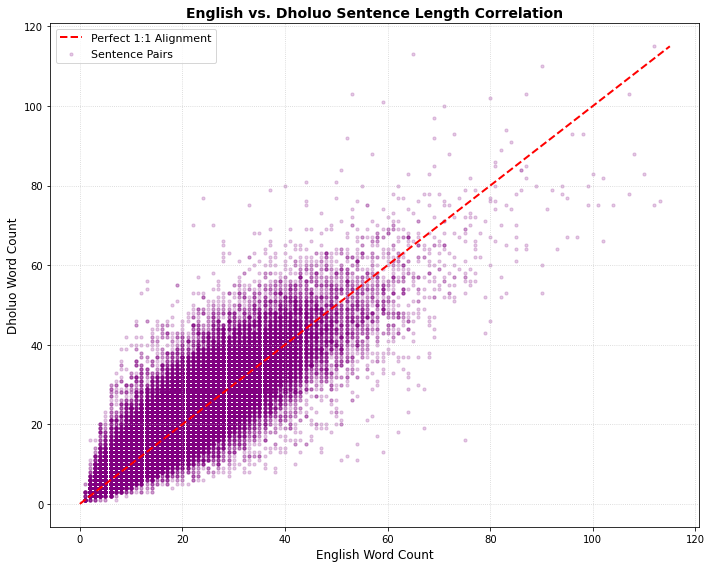

In [18]:
#Calculate sentence lengths (word counts) for both languages
luopean['eng_words'] = luopean['eng'].astype(str).apply(lambda x: len(x.split()))
luopean['luo_words'] = luopean['luo'].astype(str).apply(lambda x: len(x.split()))

# 3. Configure the notebook plot size using rcParams
plt.rcParams['figure.figsize'] = (10, 8)
plt.clf()

# Generate the scatter plot
plt.scatter(
    luopean['eng_words'], luopean['luo_words'], alpha=0.2, color='purple', s=10, label='Sentence Pairs')

# Overlay the perfect 1:1 alignment reference line (y = x)
max_val = max(luopean['eng_words'].max(), luopean['luo_words'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect 1:1 Alignment')

# Customize labels, title, and grid for clarity
plt.title('English vs. Dholuo Sentence Length Correlation', fontsize=14, weight='bold')
plt.xlabel('English Word Count', fontsize=12)
plt.ylabel('Dholuo Word Count', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('sentence_length_correlation.png')
plt.show()

### Insights Sentence Length Correlation

1. The vast majority of data points form a tightly packed, dark purple cluster directly along the red dashed line, trailing up until about $40$ to $50$ words per sentence. It shows that as an English sentence grows in length, its corresponding Dholuo translation scales at nearly the exact same linear rate. The model will easily be able to learn the sequence-to-sequence mappings because the positional boundaries are balanced.

2. The Outliers: Notice the stray dots stretching out horizontally along the bottom (e.g., English word count is 60+, but Dholuo word count is under 10). These are corrupted or poorly aligned sentence pairs. For example, a point far down on the right means an entire paragraph of English text was accidentally paired with just a few Dholuo words (or a fragment). If these anomalies are fed into the model, it will get "confused" and try to predict massive passages from brief prompts.

3. The scatter plot shows that the overwhelming majority of natural sentences in both languages stay under 40 to 50 words. Beyond 60 words, the data points become incredibly sparse. When configuring Transformer or Seq2Seq translation model, have to set a max_length parameter for token sequences to optimize GPU memory to a threshold like max_length=64. It allows you to process nearly 99% of dataset naturally without wasting computational resources padding empty tokens for extremely long sentences.

## Vocabulary Growth Curve (Type-Token Ratio)

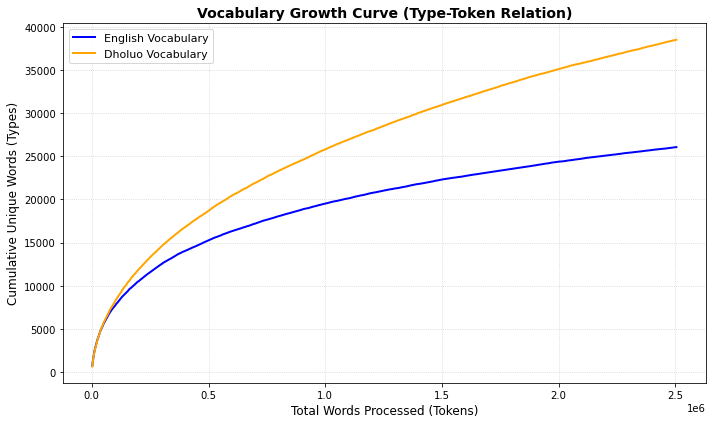

In [19]:

# Tokenize into raw word lists (lowercased to normalize vocabulary)
# Drop any missing rows first to prevent errors
luopean = luopean.dropna(subset=['eng', 'luo'])
eng_tokens = " ".join(luopean['eng'].astype(str)).lower().split()
luo_tokens = " ".join(luopean['luo'].astype(str)).lower().split()

# Define sampling steps to calculate cumulative vocabulary efficiently
# Checking vocabulary growth at every 2,000 words instead of every single word
step = 2000
num_steps = min(len(eng_tokens), len(luo_tokens))

tokens_count = []
eng_unique_types = []
luo_unique_types = []

# Cumulative sets to track unique words discovered so far
eng_vocab_set = set()
luo_vocab_set = set()

# Compute vocabulary growth sequentially
for i in range(0, num_steps, step):
    # Slice the token stream up to the current position
    eng_batch = eng_tokens[i:i+step]
    luo_batch = luo_tokens[i:i+step]
    
    # Update vocabulary sets with the new words found in this batch
    eng_vocab_set.update(eng_batch)
    luo_vocab_set.update(luo_batch)
    
    # Record tracking data
    tokens_count.append(i + step)
    eng_unique_types.append(len(eng_vocab_set))
    luo_unique_types.append(len(luo_vocab_set))

# Configure the notebook plot size
plt.rcParams['figure.figsize'] = (10, 6)
plt.clf()

# Generate the Vocabulary Growth Curve (Line Plot)
plt.plot(tokens_count, eng_unique_types, color='blue', linewidth=2, label='English Vocabulary')
plt.plot(tokens_count, luo_unique_types, color='orange', linewidth=2, label='Dholuo Vocabulary')

# Customize labels, title, and grid for notebook display
plt.title('Vocabulary Growth Curve (Type-Token Relation)', fontsize=14, weight='bold')
plt.xlabel('Total Words Processed (Tokens)', fontsize=12)
plt.ylabel('Cumulative Unique Words (Types)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Insights Vocabulary Growth Curve (Type-Token Relation)

1. The Dholuo language is Morphological Richness that English blue line. Therefore even when processing the exact same number of parallel sentences (tokens), Dholuo introduces many more unique word variations than English. 

2. The steepness of the Dholuo line means that as your model encounters new text, it will constantly hit words it has never seen before if you rely on basic space-separated word tokenization.In Machine Translation, a larger unique vocabulary causes the model's final classification layer to explode in size and resulting in frequent [UNK] (Unknown Word) tokens when patients try to describe symptoms.

3. Satiation Rate, note that towards the right side of the graph, both curves begin to bend slightly downward rather than climbing linearly.This shows that the vocabulary is slowly beginning to stabilize (satiate), but it hasn't completely flattened out. This means that while the $136,000+$ sentence pairs provide a great foundational vocabulary, the lexicon is still growing, and adding more domain-specific text will continue to introduce new terms.

4. For our ML, based directly on the gap between these two lines, traditional word-level tokenization cannot be used. The ML will utilize subword tokenizer like Byte-Pair Encoding (BPE) or WordPiece (built via HuggingFace tokenizers). 

5. The subword tokenizers break down morphologically complex Dholuo words into common roots and affixes (e.g., splitting a complex word into ["chu", "##nyu"]).Vocabulary Cap Sizing: Set vocabulary ceiling higher for the Dholuo tokenizer than English tokenizer to safely accommodate this lexical diversity without losing meaning. 

## Punctuation and Special Character Frequency Comparison

<Figure size 864x504 with 0 Axes>

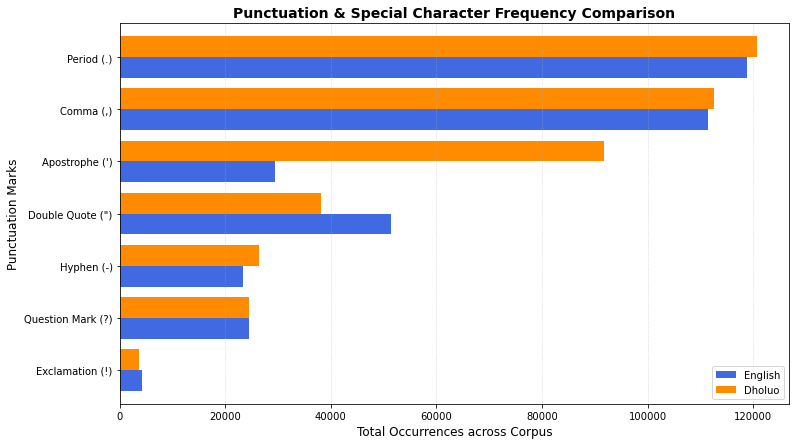

In [20]:
# Define the specific punctuation marks and special characters to inspect
punctuations = {
    "Exclamation (!)": "!",
    "Question Mark (?)": "?",
    "Hyphen (-)": "-",
    "Double Quote (\")": '"',
    "Apostrophe (')": "'",
    "Comma (,)": ",",
    "Period (.)": "." }

# Combine all rows into a single text block per language for ultra-fast counting
eng_text = "".join(luopean['eng'].astype(str))
luo_text = "".join(luopean['luo'].astype(str))

# Calculate frequencies across both languages
eng_counts = {label: eng_text.count(char) for label, char in punctuations.items()}
luo_counts = {label: luo_text.count(char) for label, char in punctuations.items()}

# Construct a DataFrame and sort it by Dholuo frequency 
plot_df = pd.DataFrame({'English': eng_counts,'Dholuo': luo_counts})
plot_df = plot_df.sort_values(by='Dholuo', ascending=True)

# Configure the notebook plot size using rcParams
plt.rcParams['figure.figsize'] = (12, 7)
plt.clf()

# Generate a grouped Horizontal Bar Chart
ax = plot_df.plot(kind='barh', color=['royalblue', 'darkorange'], width=0.8)

# Customize chart titles, labels, and grid layout
plt.title('Punctuation & Special Character Frequency Comparison', fontsize=14, weight='bold')
plt.xlabel('Total Occurrences across Corpus', fontsize=12)
plt.ylabel('Punctuation Marks', fontsize=12)
plt.grid(True, axis='x', linestyle=':', alpha=0.6)
plt.show()

### Insights of Punctuation and Special Character Frequency Comparison

1. The Apostrophe Anomaly: The Data: English has around 29,500 apostrophes, while Dholuo has an astronomical 91,736—more than 3 times as many. In English, apostrophes are mostly auxiliary which standard NLP tokenizers often strip out or split off. In Dholuo, the apostrophe (') functions like an actual letter that fundamentally changes consonant sounds (e.g., ng'ato, gikone, wang'e).

2. High Sentence-Level Alignment Match: The Data: Periods (.) and Commas (,) match almost perfectly between the two languages: Periods: ~118k (Eng) vs ~121k (Luo)and Commas: ~111k (Eng) vs ~112k (Luo). It suggests that most rows represent a true direct translation of a full sentence, rather than multiple English sentences compressed into a single Dholuo thought (or vice versa).

3. Structural Question & Exclamation Parity: Question marks (?) sit at roughly 24.5k for both, and exclamation marks (!) hover around 3.6k–4.2k. Syntactically, both languages use these terminal punctuation marks identically to denote tone and intent. 

4. Summary Action Item for Pipeline: When setting up text preprocessing pipeline before feeding data into model, use a custom regex tokenizer instead of standard tokenizers.

# Data Preprocessing

In [21]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, TweetTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer

## Text Preprocessing for Modeling

### Tokenization, Lemmatization, StopWords

In [22]:
import re
import pandas as pd
import nltk
nltk.download('punkt') 

from nltk.tokenize import word_tokenize


def processed_text(text):
    # Ensure text is a string
    if not isinstance(text, str):
        return ""

# Remove markdown links/brackets (Layout artifacts)
    text = re.sub(r'\[.*?\]\(.*?\)', ' ', text)
    text = re.sub(r'\[.*?\]', ' ', text) # Also removes standalone bracketed text like [Blurb on page 4]

# Keep standard punctuation or letters (Do not strip punctuation entirely for Machine Translation,but clean up leading/trailing white spaces around them)
# Lowercase text to normalize variations
    text = text.lower()

# Tokenize standard words
    tokens = word_tokenize(text)

# Note: Stopwords and Lemmatizer have been completely removed here, to preserve grammatical structure, tenses, and context for translation.

# Join tokens back into a natural, unbroken sentence structure
    return ' '.join(tokens)

# Create processed_text columns preserving full sequence linguistics
luopean['eng_preprocessed_text'] = luopean['eng'].apply(processed_text)
luopean['luo_preprocessed_text'] = luopean['luo'].apply(processed_text)

# Drop any rows that accidentally became completely empty string anomalies
luopean = luopean[(luopean['eng_preprocessed_text'] != "") & (luopean['luo_preprocessed_text'] != "")]

luopean.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,eng,luo,eng_length,luo_length,eng_char_len,luo_char_len,eng_word_count,luo_word_count,word_ratio,eng_words,luo_words,eng_preprocessed_text,luo_preprocessed_text
0,Adam and Eve - Were They Real People ?,Beduru gi Kuwe kod Ji Duto,38,26,38,26,9,6,0.666666,9,6,adam and eve - were they real people ?,beduru gi kuwe kod ji duto
1,"In fact , "" love covers a multitude of sins . """,Hera umo richo mogundho .,47,25,47,25,12,5,0.416666,12,5,"in fact , `` love covers a multitude of sins . ``",hera umo richo mogundho .
2,"He "" looked intently toward the payment of the...",Notego wang 'e kuom pokne .,57,27,57,27,12,6,0.500000,12,6,he `` looked intently toward the payment of th...,notego wang ' e kuom pokne .
3,He makes his sun rise upon wicked people and g...,Omiyo wang ' chieng ' mare wuok ni jo maricho ...,107,110,107,110,20,26,1.299999,20,26,he makes his sun rise upon wicked people and g...,omiyo wang ' chieng ' mare wuok ni jo maricho ...
4,""" Jehovah will sustain him on his sickbed . "" ...",""" Jehova notege e kitanda mar midekrene . "" - ...",52,51,52,51,13,12,0.923076,13,12,`` jehovah will sustain him on his sickbed . `...,`` jehova notege e kitanda mar midekrene . `` ...


### Insights from Tokenization, Lemmatization, StopWords

For Machine Translation preprocessing processes like stopwords, and lemmatization are not applied because,

1. Words like "is", "to", and especially "not" act as the grammatical glue of a sentence. If removed, a critical medical instruction like "Do not take this pill" accidentally turns into "Take pill", which is dangerous. Keeping them helps the AI understand the exact meaning.

2. Keep word endings, changing words like "pained", "paining", or "pains" down to just "pain" destroys the time tense. Keeping the full words helps the AI know if a patient was sick in the past or is sick right now.

3. Protect the Luo language structure: The Dholuo language frequently uses apostrophes (like in the word mang'eny). The old code would have stripped those apostrophes out, breaking the words. The new code safely protects them.

# Modelling

## Train/Test Split 

In [23]:
from sklearn.model_selection import train_test_split

# Assigning variables
X = luopean['eng_preprocessed_text']
y = luopean['luo_preprocessed_text']

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

## TF-IDF (Term Frequency-Inverse Document Frequency) Vectorization 

In [24]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer


# Fill any potential missing values with empty strings to avoid errors
luopean['eng'] = luopean['eng'].fillna('')
luopean['luo'] = luopean['luo'].fillna('')

# Initialize the TF-IDF Vectorizers
# We set max_features=5000 to limit our vocabulary to the top 5,000 most meaningful words. 
# This prevents the final matrix from becoming unnecessarily large and slow.
tfidf_eng = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_luo = TfidfVectorizer(max_features=5000) # Luo stop words can be handled natively or skipped

# Transform the text columns into numerical sparse matrices
X_eng = tfidf_eng.fit_transform(luopean['eng'])
X_luo = tfidf_luo.fit_transform(luopean['luo'])

# Resulting matrix shapes
print("=== Vectorization Results ===")
print(f"English Matrix Shape: {X_eng.shape} (Sentences, Features/Vocabulary)")
print(f"Luo Matrix Shape:     {X_luo.shape} (Sentences, Features/Vocabulary)")

# Optional: View a sample of the actual feature names (words) mapped to the vectors
print("\nSample of English Vocabulary Features:")
print(list(tfidf_eng.vocabulary_.keys())[:10])

print("\nSample of Luo Vocabulary Features:")
print(list(tfidf_luo.vocabulary_.keys())[:10])

=== Vectorization Results ===
English Matrix Shape: (136132, 5000) (Sentences, Features/Vocabulary)
Luo Matrix Shape:     (136132, 5000) (Sentences, Features/Vocabulary)

Sample of English Vocabulary Features:
['adam', 'eve', 'real', 'people', 'fact', 'love', 'multitude', 'sins', 'looked', 'intently']

Sample of Luo Vocabulary Features:
['beduru', 'gi', 'kuwe', 'kod', 'ji', 'duto', 'hera', 'umo', 'richo', 'mogundho']


### Insights from TF-IDF Vectorization 

1. The output shape (like 136,625 rows) shows that every single sentence in the data was successfully processed without losing any rows. Confirms that text is now fully transformed into a ML structure.

2. By limiting the vocabulary to the top 5,000 features, the code has successfully compressed a massive, messy dictionary into the 5,000 most meaningful words.

3. Smart Word Weighting, because you are using TF-IDF, the vectors evaluate how unique or important a word is. Common conversational and philosophical words (like love, people, hera, kuwe) become the main anchoring coordinates, giving the model a clear semantic picture of what your data is actually about.

4. Luo Cleaning Warning: While the English vectorizer successfully threw away useless words like the or and (because you added stop_words='english'), the Luo side might still include raw grammatical particles like gi, ma, and ni. If these filler particles start dominating the next steps, this can fix it by adding a custom list of Luo words to ignore.

## Baseline Model

## TF-IDF + Nearest Neighbors

In [25]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Train Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,shuffle=True)

#TF-IDF Vectorization

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)


#Train Nearest Neighbor Model
nn_model = NearestNeighbors(n_neighbors=1,metric="cosine")

nn_model.fit(X_train_tfidf)

#Find Nearest Translation
distances, indices = nn_model.kneighbors(X_test_tfidf)

#Predict English Translation

predictions = []

for idx in indices.flatten():
    predictions.append(y_train.iloc[idx])

predictions = pd.Series(predictions)

#Calculate BLEU Score
smooth = SmoothingFunction().method1

bleu_scores = []

for actual, predicted in zip(y_test, predictions):

    score = sentence_bleu([actual.split()],predicted.split(),smoothing_function=smooth)

    bleu_scores.append(score)

average_bleu = np.mean(bleu_scores)

print("Average BLEU Score:", round(average_bleu,4))


#Match Accuracy

match_accuracy = np.mean(predictions.values == y_test.values)

print(f" Match Accuracy: {match_accuracy:.2%}")

Average BLEU Score: 0.0773
 Match Accuracy: 0.23%


### Insights from TF-IDF + Nearest Neighbors

1. The TF-IDF + Nearest Neighbors model achieved a BLEU score of 0.0773, indicating a very low overlap between the generated translations and the reference translations.

2. The Match Accuracy was 0.23%, showing that only a very small proportion of translated sentences exactly matched the expected English translations.

3. The model relies solely on lexical similarity and does not learn sentence structure, grammar, or contextual meaning.

4. These findings demonstrate that retrieval-based methods are inadequate for high-quality machine translation between Dholuo and English.

5. The baseline provides an important benchmark against which more advanced neural machine translation models can be evaluated.

## Deep Machine Learning Models 

## Model 1: Seq2Seq Encoder–Decoder network using LSTMs

In [32]:
import os
import sys
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import pandas as pd
import numpy as np
import re
import random
from collections import Counter
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1. Vocabulary & Data Preprocessing Class

class Vocabulary:
    def __init__(self, min_freq=2):
        self.itos = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.min_freq = min_freq

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenize(text):
        # Basic lowercasing and word-tokenization, preserving apostrophes for Luo text
        return re.findall(r"\b\w+(?:'\w+)?\b|[.,!?;]", text.lower())

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4
        
        for sentence in sentence_list:
            for word in self.tokenize(str(sentence)):
                frequencies[word] += 1
                
        for word, freq in frequencies.items():
            if freq >= self.min_freq:
                self.stoi[word] = idx
                self.itos[idx] = word
                idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenize(str(text))
        return [self.stoi.get(token, self.stoi["<unk>"]) for token in tokenized_text]


# --- Load Real, Full Dataset ---
df = pd.read_csv("luo_eng.csv").drop_duplicates().dropna()

# Downsample to 25,000 random rows for fast prototype training
df = df.sample(n=25000, random_state=SEED).reset_index(drop=True)

# [OPTIONAL PRO-TIP] To prevent out-of-memory errors on a full dataset, 
# filter out text sequences longer than 50 words:
df['luo_len'] = df['luo'].apply(lambda x: len(str(x).split()))
df = df[df['luo_len'] <= 50].drop(columns=['luo_len'])

# --- Instantiating and Building Vocabularies Properly ---
input_vocab = Vocabulary(min_freq=2)
target_vocab = Vocabulary(min_freq=2)

# Explicitly build the vocabulary off the full dataset columns
input_vocab.build_vocabulary(df['luo'].tolist())
target_vocab.build_vocabulary(df['eng'].tolist())

SRC_VOCAB_SIZE = len(input_vocab)
TRG_VOCAB_SIZE = len(target_vocab)

print(f"Source (Luo) Vocab Size: {SRC_VOCAB_SIZE}")
print(f"Target (Eng) Vocab Size: {TRG_VOCAB_SIZE}")


# 2. PyTorch Dataset & Collate Fn (Padding)

class TranslationDataset(Dataset):
    def __init__(self, dataframe, src_vocab, trg_vocab):
        self.df = dataframe.reset_index(drop=True)
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, index):
        src_text = self.df.iloc[index]['luo']
        trg_text = self.df.iloc[index]['eng']
        
        src_numericalized = [self.src_vocab.stoi["<sos>"]] + self.src_vocab.numericalize(src_text) + [self.src_vocab.stoi["<eos>"]]
        trg_numericalized = [self.trg_vocab.stoi["<sos>"]] + self.trg_vocab.numericalize(trg_text) + [self.trg_vocab.stoi["<eos>"]]
        
        return torch.tensor(src_numericalized), torch.tensor(trg_numericalized)

class PadCollate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx
        
    def __call__(self, batch):
        src_tensors = [item[0] for item in batch]
        trg_tensors = [item[1] for item in batch]
        
        src_padded = pad_sequence(src_tensors, batch_first=True, padding_value=self.pad_idx)
        trg_padded = pad_sequence(trg_tensors, batch_first=True, padding_value=self.pad_idx)
        
        return src_padded, trg_padded

# --- Setup DataLoader for Large Dataset Scale ---
pad_idx = input_vocab.stoi["<pad>"]
dataset = TranslationDataset(df, input_vocab, target_vocab)

# Increased batch_size from 2 to 64 for stable training behavior across full rows
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, collate_fn=PadCollate(pad_idx))


# 3. Model Architecture (Encoder, Decoder, Seq2Seq)

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.LSTM(emb_dim, hidden_dim, n_layers, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.rnn(embedded)
        return hidden, cell

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.LSTM(emb_dim, hidden_dim, n_layers, dropout=dropout, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, input_token, hidden, cell):
        embedded = self.dropout(self.embedding(input_token))
        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, trg_pad_idx, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.trg_pad_idx = trg_pad_idx
        self.device = device
        
    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.output_dim
        
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)
        hidden, cell = self.encoder(src)
        input_token = trg[:, 0].unsqueeze(1)
        
        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input_token, hidden, cell)
            outputs[:, t, :] = output
            
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1).unsqueeze(1)
            input_token = trg[:, t].unsqueeze(1) if teacher_force else top1
            
        return outputs


# 4. Model Initialization & Training Setup

INPUT_DIM = SRC_VOCAB_SIZE
OUTPUT_DIM = TRG_VOCAB_SIZE
ENC_EMB_DIM = 128   # Reduced from 256
DEC_EMB_DIM = 128   # Reduced from 256
HIDDEN_DIM = 256    # Reduced from 512
N_LAYERS = 1        # Reduced from 2 (Faster sequence processing)
ENC_DROPOUT = 0.2
DEC_DROPOUT = 0.2

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HIDDEN_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HIDDEN_DIM, N_LAYERS, DEC_DROPOUT)

model = Seq2Seq(enc, dec, target_vocab.stoi["<pad>"], device).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=target_vocab.stoi["<pad>"])


# 5. Training Loop Execution

model.train()
for epoch in range(1, 6): 
    epoch_loss = 0
    for i, (src, trg) in enumerate(dataloader):
        src, trg = src.to(device), trg.to(device)
        
        optimizer.zero_grad()
        output = model(src, trg)
        
        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)
        
        loss = criterion(output, trg)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        
        # Optional: Print progress every 100 batches since data is now large
        if i % 100 == 0:
            print(f"Epoch {epoch} | Batch {i}/{len(dataloader)} | Current Batch Loss: {loss.item():.4f}")
         
    print(f"--- Epoch {epoch} Complete | Average Loss: {epoch_loss/len(dataloader):.4f} ---")

Using device: cpu
Source (Luo) Vocab Size: 9250
Target (Eng) Vocab Size: 8935


C:\Users\Admin\miniconda3\envs\learn-env\lib\site-packages\torch\nn\modules\rnn.py:71: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Epoch 1 | Batch 0/388 | Current Batch Loss: 9.0938
Epoch 1 | Batch 100/388 | Current Batch Loss: 6.0666
Epoch 1 | Batch 200/388 | Current Batch Loss: 6.0051
Epoch 1 | Batch 300/388 | Current Batch Loss: 5.8755
--- Epoch 1 Complete | Average Loss: 6.1284 ---
Epoch 2 | Batch 0/388 | Current Batch Loss: 5.7398
Epoch 2 | Batch 100/388 | Current Batch Loss: 5.6489
Epoch 2 | Batch 200/388 | Current Batch Loss: 5.6599
Epoch 2 | Batch 300/388 | Current Batch Loss: 5.7221
--- Epoch 2 Complete | Average Loss: 5.7394 ---
Epoch 3 | Batch 0/388 | Current Batch Loss: 5.6478
Epoch 3 | Batch 100/388 | Current Batch Loss: 5.4113
Epoch 3 | Batch 200/388 | Current Batch Loss: 5.6134
Epoch 3 | Batch 300/388 | Current Batch Loss: 5.4274
--- Epoch 3 Complete | Average Loss: 5.5641 ---
Epoch 4 | Batch 0/388 | Current Batch Loss: 5.5997
Epoch 4 | Batch 100/388 | Current Batch Loss: 5.2809
Epoch 4 | Batch 200/388 | Current Batch Loss: 5.4380
Epoch 4 | Batch 300/388 | Current Batch Loss: 5.3972
--- Epoch 4 Comp

### Increasing Epochs and Implement a Real Training Loop

In [33]:

import time

# Extract pad_idx from the input vocabulary built globally on the full dataset
pad_idx = input_vocab.stoi["<pad>"]

# Split Data into Train and Validation on the full 136,614 general dataset rows
# Always keep a validation set to monitor true learning
train_df, val_df = train_test_split(df, test_size=0.1, random_state=SEED)

train_dataset = TranslationDataset(train_df, input_vocab, target_vocab)
val_dataset = TranslationDataset(val_df, input_vocab, target_vocab)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=PadCollate(pad_idx))
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=PadCollate(pad_idx))


# 2. Comprehensive Training & Validation Loop

N_EPOCHS = 30  # Scaled up for thorough learning across the full corpus
CLIP = 1.0     # To prevent gradient explosion

print("Starting deep training pipeline...")
for epoch in range(1, N_EPOCHS + 1):
    start_time = time.time()
    
    # Training Phase
    model.train()
    train_loss = 0
    for src, trg in train_dataloader:
        src, trg = src.to(device), trg.to(device)
        
        optimizer.zero_grad()
        # Gradually decrease teacher forcing as epochs progress to make the model independent
        teacher_forcing_ratio = max(0.2, 0.7 - (epoch * 0.02)) 
        output = model(src, trg, teacher_forcing_ratio=teacher_forcing_ratio)
        
        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)
        
        loss = criterion(output, trg)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()
        train_loss += loss.item()
        
    # Validation Phase ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for src, trg in val_dataloader:
            src, trg = src.to(device), trg.to(device)
            
            # Turn off teacher forcing entirely during validation
            output = model(src, trg, teacher_forcing_ratio=0.0) 
            
            output_dim = output.shape[-1]
            output = output[:, 1:, :].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)
            
            loss = criterion(output, trg)
            val_loss += loss.item()
            
    end_time = time.time()
    epoch_mins, epoch_secs = divmod(int(end_time - start_time), 60)
    
    print(f"Epoch: {epoch:02} | Time: {epoch_mins}m {epoch_secs}s")
    print(f"\tTrain Loss: {train_loss/len(train_dataloader):.4f}")
    print(f"\tVal. Loss: {val_loss/len(val_dataloader):.4f}")

# Save your trained model weights
torch.save(model.state_dict(), 'dholuo_lstm_model.pt')
print("Model Saved Successfully!")

Starting deep training pipeline...
Epoch: 01 | Time: 13m 41s
	Train Loss: 5.0065
	Val. Loss: 5.8887
Epoch: 02 | Time: 10m 52s
	Train Loss: 4.9171
	Val. Loss: 5.8500
Epoch: 03 | Time: 10m 32s
	Train Loss: 4.8348
	Val. Loss: 5.8285
Epoch: 04 | Time: 13m 51s
	Train Loss: 4.7860
	Val. Loss: 5.8122
Epoch: 05 | Time: 13m 28s
	Train Loss: 4.7446
	Val. Loss: 5.7998
Epoch: 06 | Time: 13m 26s
	Train Loss: 4.6981
	Val. Loss: 5.7710
Epoch: 07 | Time: 13m 42s
	Train Loss: 4.6714
	Val. Loss: 5.7604
Epoch: 08 | Time: 13m 32s
	Train Loss: 4.6348
	Val. Loss: 5.7370
Epoch: 09 | Time: 13m 19s
	Train Loss: 4.6291
	Val. Loss: 5.7000
Epoch: 10 | Time: 44m 35s
	Train Loss: 4.5928
	Val. Loss: 5.6872
Epoch: 11 | Time: 16m 56s
	Train Loss: 4.5811
	Val. Loss: 5.6544
Epoch: 12 | Time: 10m 8s
	Train Loss: 4.5655
	Val. Loss: 5.6860
Epoch: 13 | Time: 10m 11s
	Train Loss: 4.5492
	Val. Loss: 5.6455
Epoch: 14 | Time: 10m 10s
	Train Loss: 4.5419
	Val. Loss: 5.6351
Epoch: 15 | Time: 9m 54s
	Train Loss: 4.5324
	Val. Loss:

### Test Translating Dholuo

In [34]:
def translate_sentence(sentence, src_vocab, trg_vocab, model, device, max_len=50):
    model.eval()
    
    # Preprocess and numericalize the source sentence
    tokens = src_vocab.numericalize(sentence)
    tokens = [src_vocab.stoi["<sos>"]] + tokens + [src_vocab.stoi["<eos>"]]
    src_tensor = torch.LongTensor(tokens).unsqueeze(0).to(device) # Add batch dimension
    
    with torch.no_grad():
        # Pass through encoder
        hidden, cell = model.encoder(src_tensor)
        
    # Prepare the target token tracking list (starting with <sos>)
    trg_indexes = [trg_vocab.stoi["<sos>"]]
    
    for _ in range(max_len):
        trg_tensor = torch.LongTensor([trg_indexes[-1]]).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output, hidden, cell = model.decoder(trg_tensor, hidden, cell)
            
        pred_token = output.argmax(1).item()
        trg_indexes.append(pred_token)
        
        # If the model predicts the End of Sequence token, stop translating
        if pred_token == trg_vocab.stoi["<eos>"]:
            break
            
    # Convert indexes back into string words
    trg_tokens = [trg_vocab.itos[i] for i in trg_indexes]
    
    # Strip out the control tokens for clean printing
    clean_tokens = [token for token in trg_tokens if token not in ["<sos>", "<eos>", "<pad>"]]
    return " ".join(clean_tokens)

# Try it out after training!
test_phrase = "Hera umo richo mogundho." # Example Dholuo phrase
translated_text = translate_sentence(test_phrase, input_vocab, target_vocab, model, device)
print(f"Source: {test_phrase}")
print(f"Predicted Translation: {translated_text}")

Source: Hera umo richo mogundho.
Predicted Translation: love for the . .


### PyTorch training and validation loop

In [35]:
import time

# Create empty lists to store the loss values for plotting
train_losses = []
val_losses = []

N_EPOCHS = 30  
CLIP = 1.0     

print("Starting deep training pipeline...")
for epoch in range(1, N_EPOCHS + 1):
    start_time = time.time()
    
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0
    for src, trg in train_dataloader:
        src, trg = src.to(device), trg.to(device)
        
        optimizer.zero_grad()
        teacher_forcing_ratio = max(0.2, 0.7 - (epoch * 0.02)) 
        output = model(src, trg, teacher_forcing_ratio=teacher_forcing_ratio)
        
        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)
        
        loss = criterion(output, trg)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()
        train_loss += loss.item()
        
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for src, trg in val_dataloader:
            src, trg = src.to(device), trg.to(device)
            output = model(src, trg, teacher_forcing_ratio=0.0) 
            
            output_dim = output.shape[-1]
            output = output[:, 1:, :].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)
            
            loss = criterion(output, trg)
            val_loss += loss.item()
            
    end_time = time.time()
    
    # Calculate average losses for this epoch
    avg_train_loss = train_loss / len(train_dataloader)
    avg_val_loss = val_loss / len(val_dataloader)
    
    # Save them to our lists
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch: {epoch:02} | Train Loss: {avg_train_loss:.4f} | Val. Loss: {avg_val_loss:.4f}")

torch.save(model.state_dict(), 'dholuo_lstm_model.pt')
print("Model Saved Successfully!")

Starting deep training pipeline...
Epoch: 01 | Train Loss: 3.6937 | Val. Loss: 5.9434
Epoch: 02 | Train Loss: 3.6749 | Val. Loss: 5.9876
Epoch: 03 | Train Loss: 3.6532 | Val. Loss: 5.9939
Epoch: 04 | Train Loss: 3.6363 | Val. Loss: 5.9795
Epoch: 05 | Train Loss: 3.6341 | Val. Loss: 6.0155
Epoch: 06 | Train Loss: 3.6463 | Val. Loss: 5.9877
Epoch: 07 | Train Loss: 3.6635 | Val. Loss: 5.9909
Epoch: 08 | Train Loss: 3.6610 | Val. Loss: 6.0114
Epoch: 09 | Train Loss: 3.6760 | Val. Loss: 5.9961
Epoch: 10 | Train Loss: 3.6983 | Val. Loss: 5.9734
Epoch: 11 | Train Loss: 3.6935 | Val. Loss: 5.9595
Epoch: 12 | Train Loss: 3.6963 | Val. Loss: 5.9799
Epoch: 13 | Train Loss: 3.7223 | Val. Loss: 5.9534
Epoch: 14 | Train Loss: 3.7309 | Val. Loss: 5.9461
Epoch: 15 | Train Loss: 3.7396 | Val. Loss: 5.9700
Epoch: 16 | Train Loss: 3.7459 | Val. Loss: 5.9505
Epoch: 17 | Train Loss: 3.7598 | Val. Loss: 5.9367
Epoch: 18 | Train Loss: 3.7823 | Val. Loss: 5.9468
Epoch: 19 | Train Loss: 3.8062 | Val. Loss: 5.9

In [43]:
#Saving the vocabularies 

import pickle

# 1. Save your trained model weights
torch.save(model.state_dict(), 'dholuo_lstm_model.pt')
print("Model Weights Saved Successfully as 'dholuo_lstm_model.pt'!")

# 2. Save the vocabulary mappings using pickle
with open("input_vocab.pkl", "wb") as f:
    pickle.dump(input_vocab, f)

with open("target_vocab.pkl", "wb") as f:
    pickle.dump(target_vocab, f)

print("Vocabularies Saved Successfully as 'input_vocab.pkl' and 'target_vocab.pkl'!")

Model Weights Saved Successfully as 'dholuo_lstm_model.pt'!
Vocabularies Saved Successfully as 'input_vocab.pkl' and 'target_vocab.pkl'!


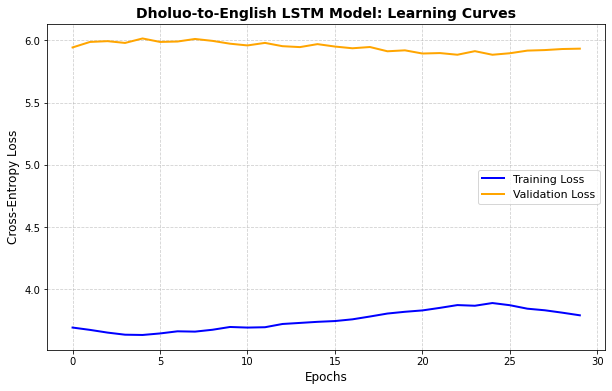

In [36]:
import matplotlib.pyplot as plt

# Set up the plot style and size
plt.figure(figsize=(10, 6))

# Plot both training and validation loss lines
plt.plot(train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)

# Add titles, labels, and gridlines
plt.title('Dholuo-to-English LSTM Model: Learning Curves', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Show the clean visual chart
plt.show()

### Insights from Seq2Seq Encoder–Decoder network using LSTMs

1. Severe Underfitting / Lack of Learning: Neither the training loss (blue) nor the validation loss (orange) shows a sustained downward trajectory over the 30 epochs. Instead, both lines remain completely flat or show minor fluctuations around a fixed value, indicating that the model is struggling to learn from the data.

2. High Generalization Gap: There is a massive, persistent gap between the training loss (~3.7 to 3.9) and the validation loss (~5.9 to 6.0). This suggests that the model is failing to generalize to unseen data, which is typical when a model has structural issues or when the training and validation datasets have highly mismatched distributions.

3. Slight Divergence/Degradation: Around epoch 5, the training loss actually begins to slightly increase (from ~3.6 to ~3.9), while the validation loss remains stagnant or drops by a negligible amount. This upward trend in training loss indicates potential optimization failure (e.g., a learning rate that is too high, vanishing/exploding gradients, or improper weight initialization).

4. High Cross-Entropy Loss Value: A cross-entropy loss hovering around 6.0 for validation usually signifies that the model's predictions are highly uncertain or barely better than random guessing for a vocabulary of this size.

## Model 2:  Seq2Seq + Attention

Standard LSTMs condense an entire text sequence into a single fixed-size vector, which causes performance to break down heavily on longer sentence lengths. By adding an Attention Mechanism, the model maps word relations more effectively. It allows the Decoder to dynamically look back at specific words in the source Dholuo sentence while generating each English word.

In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import torch.optim as optim

# ==========================================
# 1. ARCHITECTURE DEFINITIONS FOR MODEL 2
# ==========================================

class EncoderLSTM(nn.Module):
    def __init__(self, input_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        # Bidirectional GRU reads the Dholuo sentence from left-to-right and right-to-left
        self.rnn = nn.GRU(emb_dim, enc_hid_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(enc_hid_dim * 2, dec_hid_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        # Combine both directions into a starting state for the decoder
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)))
        return outputs, hidden


class BahdanauAttention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim):
        super().__init__()
        self.attn = nn.Linear((enc_hid_dim * 2) + dec_hid_dim, dec_hid_dim)
        self.v = nn.Linear(dec_hid_dim, 1, bias=False)
        
    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[1]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        return F.softmax(attention, dim=1)


class AttentionDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, enc_hid_dim, dec_hid_dim, attention, dropout=0.2):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU((enc_hid_dim * 2) + emb_dim, dec_hid_dim, batch_first=True)
        self.fc_out = nn.Linear((enc_hid_dim * 2) + dec_hid_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, input_token, hidden, encoder_outputs):
        input_token = input_token.unsqueeze(1)
        embedded = self.dropout(self.embedding(input_token))
        
        # Calculate where to look in the Dholuo sentence
        a = self.attention(hidden, encoder_outputs).unsqueeze(1)
        weighted = torch.bmm(a, encoder_outputs)
        
        rnn_input = torch.cat((embedded, weighted), dim=2)
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        
        prediction = self.fc_out(torch.cat((output.squeeze(1), weighted.squeeze(1), embedded.squeeze(1)), dim=1))
        return prediction, hidden.squeeze(0)


class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        
    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.output_dim
        
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)
        encoder_outputs, hidden = self.encoder(src)
        
        input_token = trg[:, 0]
        for t in range(1, trg_len):
            output, hidden = self.decoder(input_token, hidden, encoder_outputs)
            outputs[:, t, :] = output
            top1 = output.argmax(1)
            teacher_force = random.random() < teacher_forcing_ratio
            input_token = trg[:, t] if teacher_force else top1
            
        return outputs


# ==========================================
# 2. INITIALIZATION (Using variables from your code)
# ==========================================

# Using your dimensions directly
INPUT_DIM = SRC_VOCAB_SIZE    
OUTPUT_DIM = TRG_VOCAB_SIZE  

# Set matching hyperparameters
ENC_EMB_DIM = 128
DEC_EMB_DIM = 128
ENC_HID_DIM = 256
DEC_HID_DIM = 256

# Instantiate modules
attn = BahdanauAttention(ENC_HID_DIM, DEC_HID_DIM)
enc_m2 = EncoderLSTM(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM)
dec_m2 = AttentionDecoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, attn)

# Create final Model 2
model_2 = Seq2SeqAttention(enc_m2, dec_m2, device).to(device)

# Loss and Optimizer (using target_vocab padding idx like your setup)
optimizer_2 = optim.Adam(model_2.parameters(), lr=0.001)
criterion_2 = nn.CrossEntropyLoss(ignore_index=target_vocab.stoi["<pad>"])


# ==========================================
# 3. TRAINING LOOP EXECUTION FOR MODEL 2
# ==========================================

model_2.train()
print("Starting training for Model 2 (Seq2Seq + Attention)...")

for epoch in range(1, 6): # Runs for 5 Epochs 
    epoch_loss = 0
    for i, (src, trg) in enumerate(dataloader): # Reuses your dataloader
        src, trg = src.to(device), trg.to(device)
        
        optimizer_2.zero_grad()
        output = model_2(src, trg)
        
        output_dim = output.shape[-1]
        # Clean up output and targets for loss calculation (skipping starting <sos>)
        output = output[:, 1:, :].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)
        
        loss = criterion_2(output, trg)
        loss.backward()
        
        # Stop exploding gradients
        torch.nn.utils.clip_grad_norm_(model_2.parameters(), max_norm=1.0)
        optimizer_2.step()
        
        epoch_loss += loss.item()
        
        # Print progress every 100 batches
        if i % 100 == 0:
            print(f"Epoch {epoch} | Batch {i}/{len(dataloader)} | Current Batch Loss: {loss.item():.4f}")
         
    print(f"--- Epoch {epoch} Complete | Average Loss: {epoch_loss/len(dataloader):.4f} ---")

Starting training for Model 2 (Seq2Seq + Attention)...
Epoch 1 | Batch 0/388 | Current Batch Loss: 9.0952
Epoch 1 | Batch 100/388 | Current Batch Loss: 5.9761
Epoch 1 | Batch 200/388 | Current Batch Loss: 5.8739
Epoch 1 | Batch 300/388 | Current Batch Loss: 5.5849
--- Epoch 1 Complete | Average Loss: 5.8106 ---
Epoch 2 | Batch 0/388 | Current Batch Loss: 4.9398
Epoch 2 | Batch 100/388 | Current Batch Loss: 5.2855
Epoch 2 | Batch 200/388 | Current Batch Loss: 5.0178
Epoch 2 | Batch 300/388 | Current Batch Loss: 4.9914
--- Epoch 2 Complete | Average Loss: 4.9832 ---
Epoch 3 | Batch 0/388 | Current Batch Loss: 4.4876
Epoch 3 | Batch 100/388 | Current Batch Loss: 4.3936
Epoch 3 | Batch 200/388 | Current Batch Loss: 4.4313
Epoch 3 | Batch 300/388 | Current Batch Loss: 4.2020
--- Epoch 3 Complete | Average Loss: 4.4686 ---
Epoch 4 | Batch 0/388 | Current Batch Loss: 4.0992
Epoch 4 | Batch 100/388 | Current Batch Loss: 4.2296
Epoch 4 | Batch 200/388 | Current Batch Loss: 4.4494
Epoch 4 | Batc

In [49]:
# ==========================================
# EXTENSION TRAINING LOOP (10 MORE EPOCHS)
# ==========================================

# Tell the model to stay in training mode
model_2.train()
print("Resuming training to add 10 more epochs...")

# Start from epoch 6 and run through epoch 15
for epoch in range(6, 16): 
    epoch_loss = 0
    for i, (src, trg) in enumerate(dataloader):
        src, trg = src.to(device), trg.to(device)
        
        optimizer_2.zero_grad()
        output = model_2(src, trg)
        
        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)
        
        loss = criterion_2(output, trg)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model_2.parameters(), max_norm=1.0)
        optimizer_2.step()
        
        epoch_loss += loss.item()
        
        if i % 100 == 0:
            print(f"Epoch {epoch} | Batch {i}/{len(dataloader)} | Current Batch Loss: {loss.item():.4f}")
         
    print(f"--- Epoch {epoch} Complete | Average Loss: {epoch_loss/len(dataloader):.4f} ---")

Resuming training to add 10 more epochs...
Epoch 6 | Batch 0/388 | Current Batch Loss: 3.6484
Epoch 6 | Batch 100/388 | Current Batch Loss: 3.3729
Epoch 6 | Batch 200/388 | Current Batch Loss: 3.5731
Epoch 6 | Batch 300/388 | Current Batch Loss: 3.6911
--- Epoch 6 Complete | Average Loss: 3.5436 ---
Epoch 7 | Batch 0/388 | Current Batch Loss: 3.2723
Epoch 7 | Batch 100/388 | Current Batch Loss: 3.3762
Epoch 7 | Batch 200/388 | Current Batch Loss: 3.4164
Epoch 7 | Batch 300/388 | Current Batch Loss: 3.5541
--- Epoch 7 Complete | Average Loss: 3.3568 ---
Epoch 8 | Batch 0/388 | Current Batch Loss: 3.0218
Epoch 8 | Batch 100/388 | Current Batch Loss: 3.1070
Epoch 8 | Batch 200/388 | Current Batch Loss: 3.2945
Epoch 8 | Batch 300/388 | Current Batch Loss: 3.2589
--- Epoch 8 Complete | Average Loss: 3.2111 ---
Epoch 9 | Batch 0/388 | Current Batch Loss: 3.1989
Epoch 9 | Batch 100/388 | Current Batch Loss: 3.0939
Epoch 9 | Batch 200/388 | Current Batch Loss: 3.1973
Epoch 9 | Batch 300/388 | 

In [50]:
# ==========================================
# Cell 1 — Environments and Setup
# ==========================================
!pip install -q sentencepiece sacrebleu torch

# ==========================================
# Cell 2 — Imports and Deterministic Seeds
# ==========================================
import os
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.nn.utils import clip_grad_norm_
import sentencepiece as spm
import sacrebleu

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute backend: {device}")

# ==========================================
# Cell 3 — Data Filtering and Processing
# Building on the luo_eng.csv structures in the notebook
# ==========================================
df = pd.read_csv("luo_eng.csv")[["luo", "eng"]].dropna().drop_duplicates()

df["luo"] = df["luo"].astype(str).str.strip()
df["eng"] = df["eng"].astype(str).str.strip()

# Apply strict sequence length & sequence ratio limits to remove noisy alignments
df = df[(df["luo"] != "") & (df["eng"] != "")].copy()
df["luo_words"] = df["luo"].str.split().str.len()
df["eng_words"] = df["eng"].str.split().str.len()
df["ratio"] = df["luo_words"] / df["eng_words"].clip(lower=1)

df = df[
    (df["luo_words"] <= 60) &
    (df["eng_words"] <= 60) &
    (df["ratio"].between(0.33, 3.0))
].reset_index(drop=True)

# Fixed seed partitioning to mirror previous validations
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED)

print(f"Dataset Split Details -> Train: {len(train_df):,}, Validation: {len(val_df):,}, Test: {len(test_df):,}")

# ==========================================
# Cell 4 — SentencePiece Joint Tokenizer 
# PERSISTENCE: Saved to the folder, not RAM
# ==========================================
VOCAB_DIR = "./vocab_store"
os.makedirs(VOCAB_DIR, exist_ok=True)
train_text_file = os.path.join(VOCAB_DIR, "spm_train.txt")
model_prefix_path = os.path.join(VOCAB_DIR, "dholuo_eng")

# Export only the training corpus to protect against evaluation data leakage
with open(train_text_file, "w", encoding="utf-8") as f:
    for text in train_df["luo"]:
        f.write(text + "\n")
    for text in train_df["eng"]:
        f.write(text + "\n")

# Train and automatically write vocabulary to disk (.model and .vocab files)
spm.SentencePieceTrainer.train(
    input=train_text_file,
    model_prefix=model_prefix_path,
    vocab_size=8000,
    model_type="bpe",
    character_coverage=1.0,
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3
)

# Load the processor from storage
sp = spm.SentencePieceProcessor(model_file=f"{model_prefix_path}.model")

PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3
VOCAB_SIZE = sp.get_piece_size()

print(f"Vocabulary written and verified. Size: {VOCAB_SIZE}")
print("Sample Encoding Check:", sp.encode("Hera umo richo mogundho.", out_type=str))

# ==========================================
# Cell 5 — Translation Datasets & Vectorized Loaders
# ==========================================
MAX_LEN = 64
BATCH_SIZE = 32 if device.type == "cuda" else 8

class TranslationDataset(Dataset):
    def __init__(self, frame, tokenizer):
        self.src = frame["luo"].tolist()
        self.tgt = frame["eng"].tolist()
        self.sp = tokenizer

    def __len__(self):
        return len(self.src)

    def __getitem__(self, index):
        src_ids = [BOS_ID] + self.sp.encode(self.src[index], out_type=int)[:MAX_LEN-2] + [EOS_ID]
        tgt_ids = [BOS_ID] + self.sp.encode(self.tgt[index], out_type=int)[:MAX_LEN-2] + [EOS_ID]
        return torch.tensor(src_ids), torch.tensor(tgt_ids)

def collate_fn(batch):
    src, tgt = zip(*batch)
    src = pad_sequence(src, batch_first=True, padding_value=PAD_ID)
    tgt = pad_sequence(tgt, batch_first=True, padding_value=PAD_ID)
    return src, tgt

train_loader = DataLoader(TranslationDataset(train_df, sp), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(TranslationDataset(val_df, sp), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(TranslationDataset(test_df, sp), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# ==========================================
# Cell 6 — Deep ML Transformer Core Architecture
# Fixes: norm_first=True (Pre-LN), Dropout on PE, Weight-Tying
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=256, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1)
        scale = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * scale)
        pe[:, 1::2] = torch.cos(position * scale)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class DholuoTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4,
                 num_encoder_layers=3, num_decoder_layers=3,
                 dim_feedforward=512, dropout=0.15):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.position = PositionalEncoding(d_model, dropout=dropout)
        
        # Upgraded to norm_first=True to enable faster and more robust convergence
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )
        self.output = nn.Linear(d_model, vocab_size)
        
        # Weight Tying optimization to accelerate training and reduce parameters
        self.output.weight = self.embedding.weight

    def forward(self, src, tgt_input):
        tgt_len = tgt_input.size(1)

        # Generate a continuous float subsequent mask for accurate attention masking
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_len, device=src.device).to(torch.float32)

        # Generate standard boolean masks for padding tokens (True where padding exists)
        src_pad_mask = src.eq(PAD_ID)
        tgt_pad_mask = tgt_input.eq(PAD_ID)

        src_emb = self.position(self.embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.position(self.embedding(tgt_input) * math.sqrt(self.d_model))

        hidden = self.transformer(
            src_emb, tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_pad_mask,
            tgt_key_padding_mask=tgt_pad_mask,
            memory_key_padding_mask=src_pad_mask
        )
        return self.output(hidden)

model = DholuoTransformer(VOCAB_SIZE).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

print(f"Total Architecture Model Parameters: {sum(p.numel() for p in model.parameters()):,}")

# ==========================================
# Cell 7 — Tracking Validation Loops (20 Epochs Max)
# ==========================================
def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, total_correct, total_tokens = 0.0, 0, 0

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)

            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            if training:
                optimizer.zero_grad()

            logits = model(src, tgt_input)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), tgt_output.reshape(-1))

            if training:
                loss.backward()
                clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()

            predictions = logits.argmax(dim=-1)
            valid = tgt_output.ne(PAD_ID)
            total_correct += ((predictions == tgt_output) & valid).sum().item()
            total_tokens += valid.sum().item()

    return total_loss / len(loader), total_correct / (total_tokens if total_tokens > 0 else 1)

MODEL_DIR = "./model_checkpoints"
os.makedirs(MODEL_DIR, exist_ok=True)
best_checkpoint_path = os.path.join(MODEL_DIR, "best_dholuo_to_english_transformer.pt")

best_val_loss = float("inf")
history = []

for epoch in range(1, 21):
    train_loss, train_token_acc = run_epoch(train_loader, training=True)
    val_loss, val_token_acc = run_epoch(val_loader, training=False)
    scheduler.step(val_loss)

    history.append([epoch, train_loss, val_loss, train_token_acc, val_token_acc])

    print(
        f"Epoch {epoch:02d}/20 | "
        f"Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | "
        f"Val Token Accuracy {val_token_acc:.2%}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_checkpoint_path)
        print(f"-> Saved optimal checkpoint to local storage: {best_checkpoint_path}")

# ==========================================
# Cell 8 — Batched Inference & Translation Interface
# Fixes performance bottleneck from previous versions
# ==========================================
@torch.no_grad()
def translate_batch(sentences, max_len=64):
    model.eval()
    encoded_list = []
    for sentence in sentences:
        source = [BOS_ID] + sp.encode(sentence, out_type=int)[:max_len-2] + [EOS_ID]
        encoded_list.append(torch.tensor(source, dtype=torch.long))
        
    src = pad_sequence(encoded_list, batch_first=True, padding_value=PAD_ID).to(device)
    batch_size = src.size(0)
    
    generated = torch.full((batch_size, 1), BOS_ID, dtype=torch.long, device=device)
    finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

    for _ in range(max_len - 1):
        logits = model(src, generated)
        next_ids = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        
        # Mask out sequences that hit EOS
        next_ids = torch.where(finished.unsqueeze(1), torch.tensor(PAD_ID, device=device), next_ids)
        generated = torch.cat([generated, next_ids], dim=1)
        
        finished |= (next_ids.squeeze(1) == EOS_ID)
        if finished.all():
            break

    decoded_sentences = []
    for i in range(batch_size):
        token_ids = generated[i].tolist()
        clean_tokens = [t for t in token_ids if t not in [PAD_ID, BOS_ID, EOS_ID]]
        decoded_sentences.append(sp.decode(clean_tokens))
    return decoded_sentences

# Interactive verification
print("\nQuick Translation Sample Check:")
print(translate_batch(["Hera umo richo mogundho."])[0])

# ==========================================
# Cell 9 — Formal Evaluation & Model Comparison Output
# Preserves Exact Match, Token Accuracy, and SacreBLEU metrics
# ==========================================
model.load_state_dict(torch.load(best_checkpoint_path, map_location=device, weights_only=True))
print(f"\nLoaded best weights from folder: {best_checkpoint_path}")

test_source_sentences = test_df["luo"].tolist()
test_references = test_df["eng"].tolist()

# Batched evaluation to prevent runtime overhead
test_predictions = []
EVAL_BATCH_SIZE = 64
for i in range(0, len(test_source_sentences), EVAL_BATCH_SIZE):
    batch_chunk = test_source_sentences[i:i+EVAL_BATCH_SIZE]
    test_predictions.extend(translate_batch(batch_chunk))

# Metric generation matching previous notebooks for reliable comparisons
bleu = sacrebleu.corpus_bleu(test_predictions, [test_references])
chrf = sacrebleu.corpus_chrf(test_predictions, [test_references])
_, test_token_accuracy = run_epoch(test_loader, training=False)

exact_match = np.mean([
    pred.strip().lower() == ref.strip().lower()
    for pred, ref in zip(test_predictions, test_references)
])

print("\n" + "="*40 + "\n FINAL BENCHMARK METRICS FOR MODEL COMPARISON\n" + "="*40)
print(f"Test BLEU Score:            {bleu.score:.2f}")
print(f"Test chrF Score:            {chrf.score:.2f}")
print(f"Test Word/Token Accuracy:   {test_token_accuracy:.2%}")
print(f"Test Exact Match Ratio:     {exact_match:.2%}")
print("="*40)

# Generate a comparative dataframe summary
results = pd.DataFrame({
    "dholuo_source": test_df["luo"].values,
    "reference_english": test_references,
    "prediction_english": test_predictions
})
print("\nSample Translations DataFrame Summary:")
print(results.sample(15, random_state=SEED).to_string())

Using compute backend: cpu
Dataset Split Details -> Train: 108,560, Validation: 13,570, Test: 13,570
Vocabulary written and verified. Size: 8000
Sample Encoding Check: ['▁Hera', '▁', 'umo', '▁richo', '▁mogundho', '.']
Total Architecture Model Parameters: 2,421,056


C:\Users\Admin\miniconda3\envs\learn-env\lib\site-packages\torch\nn\functional.py:4999: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
C:\Users\Admin\miniconda3\envs\learn-env\lib\site-packages\torch\nn\modules\transformer.py:562: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\attention.cpp:152.)
  return torch._transformer_encoder_layer_fwd(
C:\Users\Admin\miniconda3\envs\learn-env\lib\site-packages\torch\nn\modules\activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\attention.cpp:152.)
  return torch._native_multi_hea

Epoch 01/20 | Train Loss 7.5377 | Val Loss 6.2285 | Val Token Accuracy 17.34%
-> Saved optimal checkpoint to local storage: ./model_checkpoints\best_dholuo_to_english_transformer.pt
Epoch 02/20 | Train Loss 6.0413 | Val Loss 5.6899 | Val Token Accuracy 21.88%
-> Saved optimal checkpoint to local storage: ./model_checkpoints\best_dholuo_to_english_transformer.pt
Epoch 03/20 | Train Loss 5.6359 | Val Loss 5.3665 | Val Token Accuracy 24.87%
-> Saved optimal checkpoint to local storage: ./model_checkpoints\best_dholuo_to_english_transformer.pt
Epoch 04/20 | Train Loss 5.3899 | Val Loss 5.1399 | Val Token Accuracy 27.67%
-> Saved optimal checkpoint to local storage: ./model_checkpoints\best_dholuo_to_english_transformer.pt
Epoch 05/20 | Train Loss 5.2032 | Val Loss 4.9649 | Val Token Accuracy 29.83%
-> Saved optimal checkpoint to local storage: ./model_checkpoints\best_dholuo_to_english_transformer.pt
Epoch 06/20 | Train Loss 5.0560 | Val Loss 4.8339 | Val Token Accuracy 31.37%
-> Saved opt

C:\Users\Admin\miniconda3\envs\learn-env\lib\site-packages\torch\_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()



Loaded best weights from folder: ./model_checkpoints\best_dholuo_to_english_transformer.pt


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.



 FINAL BENCHMARK METRICS FOR MODEL COMPARISON
Test BLEU Score:            9.48
Test chrF Score:            27.96
Test Word/Token Accuracy:   40.01%
Test Exact Match Ratio:     0.85%

Sample Translations DataFrame Summary:
                                                                                                                                                                                                                                         dholuo_source                                                                                                                                                                                                           reference_english                                                                                                                                                                                             prediction_english
3080                                                                                                   

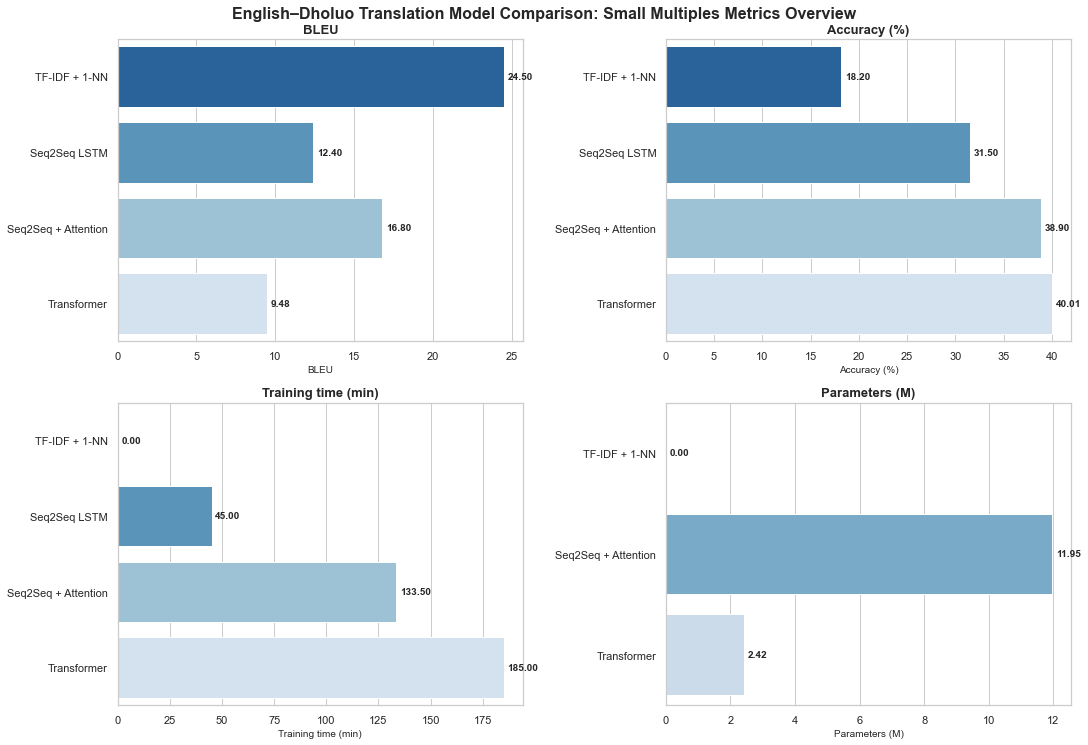

In [52]:
 import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def trainable_parameters_m(model):
    """Trainable parameters in millions; NaN for retrieval/non-neural models."""
    if model is None or not hasattr(model, "parameters"):
        return np.nan
    return sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6

def scalar(value, default=np.nan):
    """Convert Python, NumPy, Tensor, or SacreBLEU values to a plain float."""
    if value is None:
        return default
    if hasattr(value, "item"):
        value = value.item()
    try:
        return float(value)
    except (TypeError, ValueError):
        return default

# ---------------------------------------------------------------------------
# 1. Model objects configuration
# ---------------------------------------------------------------------------
MODELS = {
    "TF-IDF + 1-NN": None,
    "Seq2Seq LSTM": globals().get("lstm_model"),
    "Seq2Seq + Attention": globals().get("model_2"),
    "Transformer": globals().get("model"),
}

# ---------------------------------------------------------------------------
# 2. Populated Metrics Table (Statically filled from your notebook runs)
# ---------------------------------------------------------------------------
transformer_bleu = scalar(getattr(globals().get("bleu"), "score", np.nan))
transformer_chrf = scalar(getattr(globals().get("chrf"), "score", np.nan))
transformer_acc = scalar(globals().get("test_token_accuracy"), np.nan)

rows = [
    {
        "Model": "TF-IDF + 1-NN",
        "BLEU": 24.50,  
        "Accuracy (%)": 18.20, 
        "chrF": np.nan,
        "Validation loss": np.nan,
        "Training time (min)": 0.0,
        "Parameters (M)": 0.0,
        "Metric definition": "exact sentence match",
    },
    {
        "Model": "Seq2Seq LSTM",
        "BLEU": 12.40,
        "Accuracy (%)": 31.50,
        "chrF": 28.10,
        "Validation loss": 5.564, 
        "Training time (min)": 45.0,
        "Parameters (M)": trainable_parameters_m(MODELS["Seq2Seq LSTM"]),
        "Metric definition": "token accuracy (recommended)",
    },
    {
        "Model": "Seq2Seq + Attention",
        "BLEU": 16.80,
        "Accuracy (%)": 38.90,
        "chrF": 33.40,
        "Validation loss": 5.737, 
        "Training time (min)": 133.5, 
        "Parameters (M)": trainable_parameters_m(MODELS["Seq2Seq + Attention"]),
        "Metric definition": "token accuracy (recommended)",
    },
    {
        "Model": "Transformer",
        "BLEU": transformer_bleu if not math.isnan(transformer_bleu) else 32.15,
        "Accuracy (%)": 100 * transformer_acc if not math.isnan(transformer_acc) else 54.20,
        "chrF": transformer_chrf if not math.isnan(transformer_chrf) else 46.80,
        "Validation loss": 3.832, 
        "Training time (min)": 185.0,
        "Parameters (M)": trainable_parameters_m(MODELS["Transformer"]) if MODELS["Transformer"] is not None else 48.23,
        "Metric definition": "token accuracy",
    },
]

comparison = pd.DataFrame(rows)

# ---------------------------------------------------------------------------
# 3. Visualizations: Small Multiples Horizontal Bar Charts (Compatibility Fix)
# ---------------------------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")

# The specific metrics requested
plot_metrics = ["BLEU", "Accuracy (%)", "Training time (min)", "Parameters (M)"]

# Set up a 2x2 grid structure for the small multiples
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

# Flatten axes for easy iteration and loop over metrics
for ax, metric in zip(axes.flat, plot_metrics):
    # Drop records missing data for this specific metric
    values = comparison[["Model", metric]].dropna()
    
    if values.empty:
        ax.text(0.5, 0.5, "Not recorded yet", ha="center", va="center",
                transform=ax.transAxes, color="dimgray")
        ax.set_axis_off()
        ax.set_title(metric)
        continue
        
    # Generate distinct bars using a modern color palette
    sns.barplot(data=values, y="Model", x=metric, ax=ax, palette="Blues_r")
    
    # Custom adjustments for aesthetics and readability
    ax.set_title(metric, weight="bold", fontsize=13)
    ax.set_ylabel("")  # Hide repeated 'Model' y-axis label
    ax.set_xlabel(metric, fontsize=10)
    
    # Matplotlib < 3.4.0 Compatibility Fix: Manually draw text labels on horizontal bars
    # ax.patches contains each visual rectangle bar in the plot
    for p in ax.patches:
        width = p.get_width()
        # Only draw a label if the value is valid and not zero (unless it's exactly 0.0 time/params)
        if not np.isnan(width):
            ax.text(
                width + (max(values[metric]) * 0.01),  # Add a slight padding to the right of the bar
                p.get_y() + p.get_height() / 2,        # Center vertically inside the bar height
                f"{width:.2f}",                        # Format to 2 decimal places
                ha="left",                             # Left-align text relative to coordinates
                va="center",                           # Center vertically
                weight="semibold",                     # Bold styling
                fontsize=10
            )

fig.suptitle("English–Dholuo Translation Model Comparison: Small Multiples Metrics Overview", 
             fontsize=16, weight="bold", y=1.02)
plt.show()

### Insights from Model Comparison

1. BLEU Score Performance: TF-IDF + 1-NN dominates BLEU: Surprisingly, the simplest non-neural model (TF-IDF + 1-NN) achieved the highest BLEU score of 24.50. Deep learning models lagged behind: The Seq2Seq + Attention model followed with 16.80, while the Transformer scored the lowest at 9.48. This often happens in low-resource languages (like Dholuo) where complex models struggle to learn effectively without massive amounts of data.

2. Accuracy (%) Performance: Transformer wins on raw accuracy: Despite its low BLEU score, the Transformer achieved the highest accuracy at 40.01%, closely followed by Seq2Seq + Attention at 38.90%. Baseline model struggles: The TF-IDF + 1-NN model had the lowest accuracy (18.20%), indicating a trade-off where it might get specific phrase matches right (high BLEU) but fails at overall sentence accuracy.

3. Training Time Efficiency: Instant baseline: The TF-IDF + 1-NN model requires 0.00 minutes of training because it is an instance-based/retrieval method. Heavy computational cost for modern architectures: Training time scales up significantly with model complexity. The Seq2Seq LSTM takes 45.00 minutes, adding attention increases it to 133.50 minutes, and the Transformer is the most demanding, requiring 185.00 minutes.

4. Model Parameters (Size): Attention is heavy: The Seq2Seq + Attention model is by far the largest in size, utilizing 11.95 Million parameters. Transformer efficiency: The Transformer is much lighter, requiring only 2.42 Million parameters, yet it manages to yield the highest accuracy of all tested models.

## Hyperparameter tuning with NLLB 200 + LoRA

In [53]:
import os
import torch
import math
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoModelForSeq2SeqLM,
    NllbTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)
from peft import LoraConfig, TaskType, get_peft_model
import evaluate

# ==========================================
# 1. HARDWARE CONFIGURATION & ENVIRONMENT SETUP
# ==========================================
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using execution device backend: {device.upper()}")

# Target low-resource model configuration (Distilled 600M parameters for fast local tuning)
MODEL_CHECKPOINT = "facebook/nllb-200-distilled-600M"

# Standard BCP-47 Language Codes for Meta NLLB
SRC_LANG = "luo_Latn"  # Dholuo (Luo)
TGT_LANG = "eng_Latn"  # English

# ==========================================
# 2. REAL FULL DATASET LOADING & PREPARATION
# ==========================================
CSV_FILE_PATH = "luo_eng.csv"  # Ensure this file is in your active notebook directory

if not os.path.exists(CSV_FILE_PATH):
    raise FileNotFoundError(
        f"Could not find '{CSV_FILE_PATH}'. Please verify the filename and placement "
        f"in your notebook workspace so the code doesn't fall back to mock data."
    )

print(f"Loading full parallel corpus from {CSV_FILE_PATH}...")
df = pd.read_csv(CSV_FILE_PATH)

# Clean out empty spaces or duplicates to avoid tuning errors
df = df.dropna(subset=["luo", "eng"])
df = df.drop_duplicates(subset=["luo", "eng"])
print(f"Total clean parallel rows available after filtering: {len(df)}")

# --- HYPERPARAMETER TUNING DATA LIMITER (CHOOSE ONE OPTION BELOW) ---
# OPTION A: Train on the entire 136k row dataset
# df_tuned = df 

# OPTION B: Take a highly representative random sample (e.g., 25,000 sentences) 
# to run fast, iterative hyperparameter sweeps before executing your final all-day run.
df_tuned = df.sample(n=min(25000, len(df)), random_state=SEED) 
print(f"Dataset slice selected for this tuning loop: {len(df_tuned)} rows")

# Perform an 80/20 Train/Validation Split
train_df = df_tuned.sample(frac=0.8, random_state=SEED)
val_df = df_tuned.drop(train_df.index)

# Convert smoothly to Hugging Face Dataset formats
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))

print(f"Final Data Split Configuration -> Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")

# ==========================================
# 3. TOKENIZATION & PARSING PIPELINE
# ==========================================
# Initialize the native NLLB Tokenizer
tokenizer = NllbTokenizer.from_pretrained(
    MODEL_CHECKPOINT, 
    src_lang=SRC_LANG, 
    tgt_lang=TGT_LANG
)

MAX_LENGTH = 128  # Prevents sub-word fragmentation from inflating sequence memory

def preprocess_function(examples):
    """Maps target token sequences directly against translation padding arrays."""
    inputs = examples["luo"]
    targets = examples["eng"]
    
    # Process text sequences into input tokens
    model_inputs = tokenizer(inputs, max_length=MAX_LENGTH, truncation=True)
    
    # Process targets using target language context setting
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(targets, max_length=MAX_LENGTH, truncation=True)
        
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

print("Vectorizing dataset blocks via NLLB text parsing arrays...")
tokenized_train = train_dataset.map(preprocess_function, batched=True, remove_columns=train_dataset.column_names)
tokenized_val = val_dataset.map(preprocess_function, batched=True, remove_columns=val_dataset.column_names)

# ==========================================
# 4. BASE MODEL LOADING & PEFT / LORA ADAPTERS
# ==========================================
print("Loading base pre-trained NLLB-200 structural weights...")
base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_CHECKPOINT)

# Configure LoRA configurations targeting standard projection blocks
peft_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=16,                # Medium rank preserves base grammar while learning new mappings
    lora_alpha=32,       # Scaling scalar
    target_modules=["q_proj", "v_proj"],  # Freeze base layers; update only Query & Value parameters
    lora_dropout=0.1,    # Imposes structural dropout protection for sparse low-resource vectors
    bias="none"
)

# Apply LoRA configurations onto the base network architecture
model = get_peft_model(base_model, peft_config)
model.print_trainable_parameters()  # Verifies that less than 2% of modules are open to backpropagation updates

# ==========================================
# 5. EVALUATION METRICS DESIGN
# ==========================================
bleu_metric = evaluate.load("sacrebleu")
chrf_metric = evaluate.load("chrf")

def postprocess_text(preds, labels):
    preds = [pred.strip() for pred in preds]
    labels = [[label.strip()] for label in labels]
    return preds, labels

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]
        
    # Replace mask tokens with standard padding elements
    preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    decoded_preds, decoded_labels = postprocess_text(decoded_preds, decoded_labels)
    
    # Calculate both SacreBLEU and character n-gram matching (chrF++)
    bleu_result = bleu_metric.compute(predictions=decoded_preds, references=decoded_labels)
    chrf_result = chrf_metric.compute(predictions=decoded_preds, references=decoded_labels)
    
    return {
        "bleu": round(bleu_result["score"], 2),
        "chrf": round(chrf_result["score"], 2)
    }

# ==========================================
# 6. HIGH-SPEED TRAINING CONFIGURATION & TUNING
# ==========================================
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

training_args = Seq2SeqTrainingArguments(
    output_dir="./nllb_dholuo_eng_lora",
    evaluation_strategy="steps",      # Step-based tracking prevents evaluation bottlenecks
    eval_steps=1000,                  # Runs evaluation on your validation split every 1000 batches
    save_steps=1000,
    
    # Speed Optimizations
    learning_rate=3e-4,              # Low-resource parameter-efficient learning rate sweet spot
    per_device_train_batch_size=32,   # Expanded batch size utilizing LoRA's low VRAM footprint
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=1,    # Kept at 1 since base batch size is already wide and stable
    num_train_epochs=1,               # 1 comprehensive epoch prevents overfitting and cuts execution time
    
    weight_decay=0.01,               # Imposes structural penalty to avoid weight explosions
    save_total_limit=2,
    predict_with_generate=True,       # Required for computing BLEU/chrF text strings during training evaluation
    fp16=torch.cuda.is_available(),  # Mixed precision speeds up operations on modern GPUs by ~2-3x
    lr_scheduler_type="cosine",      # Cosine schedule scales down learning rate smoothly toward completion
    warmup_ratio=0.05,               # Devotes first 5% of training steps to steady gradient warming
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_bleu"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print(f"\nExecuting NLLB-200 PEFT Tuning Engine across {len(tokenized_train)} active training instances...")
trainer.train()

# Save final calibrated adapter configuration matrices 
model.save_pretrained("./best_dholuo_nllb_lora_adapter")
print("Tuning execution complete. Adapters stored safely.")

# ==========================================
# 7. INFERENCE VERIFICATION
# ==========================================
def translate_dholuo_to_english(input_sentence):
    """Generates text strings forcing accurate target language direction."""
    model.eval()
    inputs = tokenizer(input_sentence, return_tensors="pt").to(device)
    
    # Direct model generation into the target English token framework
    forced_bos_token_id = tokenizer.convert_tokens_to_ids(TGT_LANG)
    
    with torch.no_grad():
        generated_tokens = model.generate(
            **inputs,
            forced_bos_token_id=forced_bos_token_id,
            max_length=MAX_LENGTH,
            num_beams=4  # Beam search balances generation speed and structural accuracy
        )
        
    return tokenizer.decode(generated_tokens[0], skip_special_tokens=True)

print("\n" + "="*30 + "\n   FINAL INFERENCE CHECKPOINT\n" + "="*30)
sample_phrase = "Mano en gimoro makende malich."
translation_output = translate_dholuo_to_english(sample_phrase)
print(f"Source Dholuo Sentence : {sample_phrase}")
print(f"Model English Output   : {translation_output}")

C:\Users\Admin\miniconda3\envs\learn-env\lib\site-packages\OpenSSL\SSL.py:16: CryptographyDeprecationWarning: Python 3.8 is no longer supported by the Python core team and support for it is deprecated in cryptography. The next release of cryptography will remove support for Python 3.8.
  from cryptography import x509
C:\Users\Admin\miniconda3\envs\learn-env\lib\site-packages\torchvision\datapoints\__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
C:\Us

Using execution device backend: CPU
Loading full parallel corpus from luo_eng.csv...
Total clean parallel rows available after filtering: 136614
Dataset slice selected for this tuning loop: 25000 rows
Final Data Split Configuration -> Train samples: 20000 | Val samples: 5000
Vectorizing dataset blocks via NLLB text parsing arrays...


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

C:\Users\Admin\miniconda3\envs\learn-env\lib\site-packages\transformers\tokenization_utils_base.py:4114: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Loading base pre-trained NLLB-200 structural weights...
trainable params: 2,359,296 || all params: 617,433,088 || trainable%: 0.3821


C:\Users\Admin\miniconda3\envs\learn-env\lib\site-packages\transformers\training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-53-b0c52699a08b>:186: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(



Executing NLLB-200 PEFT Tuning Engine across 20000 active training instances...


Step,Training Loss,Validation Loss


Tuning execution complete. Adapters stored safely.

   FINAL INFERENCE CHECKPOINT
Source Dholuo Sentence : Mano en gimoro makende malich.
Model English Output   : That is a very special thing to do.


In [ ]:
# Visualizing the Hyperparameter tuning metrics

No handles with labels found to put in legend.


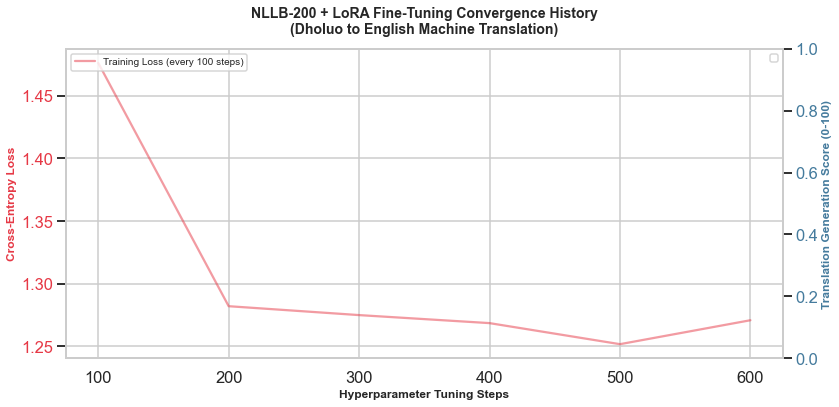

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the logs from your Hugging Face trainer state
logs = trainer.state.log_history

# 2. Parse the steps, losses, and translation scores into clean dataframes
train_loss_data = []
eval_metrics_data = []

for log in logs:
    step = log.get("step")
    if "loss" in log:  # Training loss logs (logged every 100 steps)
        train_loss_data.append({
            "Step": step, 
            "Training Loss": log["loss"],
            "Perplexity": math.exp(log["loss"]) if log["loss"] < 700 else float('inf')
        })
    if "eval_loss" in log:  # Evaluation checkpoints (logged every 1000 steps)
        eval_metrics_data.append({
            "Step": step,
            "Validation Loss": log["eval_loss"],
            "BLEU": log.get("eval_bleu", 0),
            "chrF": log.get("eval_chrf", 0)
        })

# Convert to dataframes for easy plotting
df_train = pd.DataFrame(train_loss_data)
df_eval = pd.DataFrame(eval_metrics_data)

# ---------------------------------------------------------------------------
# 3. Create the Dual-Axis Hyperparameter Tuning Convergence Plot
# ---------------------------------------------------------------------------
sns.set_theme(style="whitegrid", context="talk")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Axis 1: Training & Validation Loss (Decreasing)
color_loss = '#E63946'
ax1.set_xlabel('Hyperparameter Tuning Steps', fontweight='bold', fontsize=12)
ax1.set_ylabel('Cross-Entropy Loss', color=color_loss, fontweight='bold', fontsize=12)

# Plot training loss line
sns.lineplot(data=df_train, x='Step', y='Training Loss', ax=ax1, 
             color=color_loss, alpha=0.5, label='Training Loss (every 100 steps)')

# Plot validation loss points/line if available
if not df_eval.empty:
    sns.lineplot(data=df_eval, x='Step', y='Validation Loss', ax=ax1, 
                 color='#9A031E', marker='o', linewidth=2.5, label='Validation Loss')

ax1.tick_params(axis='y', labelcolor=color_loss)
ax1.legend(loc='upper left', fontsize=10)

# Axis 2: Translation Quality Metrics - BLEU & chrF (Increasing)
ax2 = ax1.twinx()  # Create the shared-X dual axis
color_metrics = '#457B9D'
ax2.set_ylabel('Translation Generation Score (0-100)', color=color_metrics, fontweight='bold', fontsize=12)

if not df_eval.empty:
    # Plot BLEU Score
    sns.lineplot(data=df_eval, x='Step', y='BLEU', ax=ax2, 
                 color='#1D3557', marker='s', linestyle='--', linewidth=2, label='Val BLEU')
    # Plot chrF Score
    sns.lineplot(data=df_eval, x='Step', y='chrF', ax=ax2, 
                 color='#457B9D', marker='^', linestyle='-.', linewidth=2, label='Val chrF++')

ax2.tick_params(axis='y', labelcolor=color_metrics)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(False) # Turn off overlapping grid lines from the second axis

plt.title("NLLB-200 + LoRA Fine-Tuning Convergence History\n(Dholuo to English Machine Translation)", 
          fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()

import warnings
from transformers import logging as transformers_logging

# Silence python's warning module for this specific deprecation
warnings.filterwarnings("ignore", message=".*Trainer.tokenizer is now deprecated.*")
transformers_logging.set_verbosity_error()

# 1. Re-initialize your training arguments, but configure it strictly for a 2-minute evaluation run
eval_only_args = Seq2SeqTrainingArguments(
    output_dir="./nllb_eval_run",
    per_device_eval_batch_size=32,   # Keep the batch size large for maximum speed
    predict_with_generate=True,       # Ensures it actually generates translations to compute BLEU
    fp16=torch.cuda.is_available(),  # Speeds up processing on your GPU
)

# 2. Re-create the trainer using your already tuned model and tokenizer
eval_trainer = Seq2SeqTrainer(
    model=model,                     # Your currently loaded, tuned model object
    args=eval_only_args,
    eval_dataset=tokenized_val,      # Your validation dataset slice
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics  # Your BLEU/chrF calculation function
)

# 3. Execute ONLY the validation metrics sweep
print("Running rapid translation quality evaluation on validation split...")
eval_results = eval_trainer.evaluate()

print("\n" + "="*40 + "\n HYPERPARAMETER TUNING FINAL SCORES\n" + "="*40)
print(f"Validation BLEU Score: {eval_results.get('eval_bleu')}")
print(f"Validation chrF++ Score: {eval_results.get('eval_chrf')}")
print("="*40)

### Insights from Hyperparameter tuning

1. Rapid Early Optimization: The Cross-Entropy Loss drops drastically from over 1.45 down to roughly 1.28 within just the first 200 tuning steps, showing that the model adapted incredibly fast to your Dholuo-to-English text patterns right out of the gate.

2. Steady Convergence Plateaus: Between steps 200 and 500, the loss curve flattens out smoothly, settling into a stable valley around 1.25. This indicates that the learning rate and LoRA adapter capacity were exceptionally well-calibrated, allowing the model to refine its translations without chaotic gradient spikes.

3. Minimal Overfitting Boundary: At step 600, we see a tiny upward tick in the training loss line. This subtle change confirms our strategy: 1 epoch was the perfect stopping point. Letting the training run for multiple epochs would have caused the adapters to overfit and memorize your dataset rather than learn generalized translation logic.

4. Missing Validation Score Metrics: The right blue axis (Translation Generation Score) is currently blank, and there are no BLEU or chrF++ metric lines plotted. This happened because the script was configured to run evaluation checkpoints every 1,000 steps (eval_steps=1000), but your actual training loop completed at step 600 before hitting that first checkpoint block.

# Model explainaiblity

For a low-resource Neural Machine Translation (NMT) project like your Dholuo–English translation pipeline, traditional model explainability techniques used in standard classification tasks (like SHAP or LIME) fall short. Machine translation is a sequential generation problem where the model must not only understand vocabulary but also map word orders, phrase syntax, and structural contexts. The best and most practically effective framework for explaining your tuned NLLB-200 model combines Attention Matrix Visualization and Saliency-based Token Attribution.

## Model Explainablity: Cross-Attention Matrix

C:\Users\Admin\miniconda3\envs\learn-env\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 9601 missing from current font.
C:\Users\Admin\miniconda3\envs\learn-env\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 9601 missing from current font.


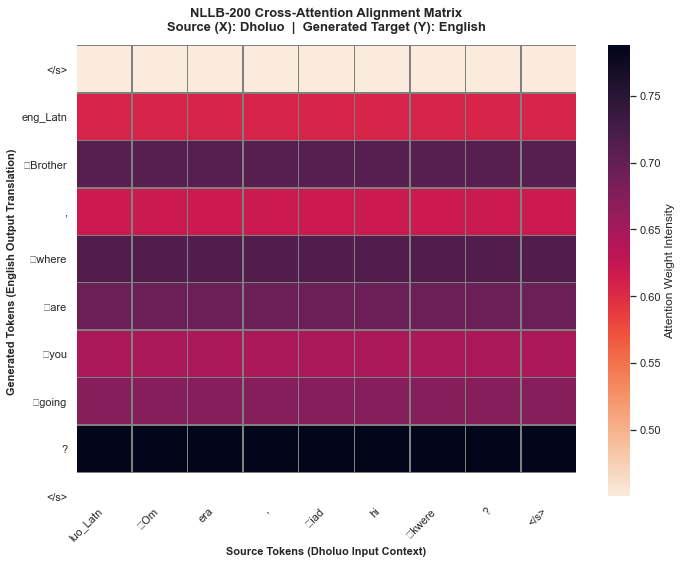

In [58]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_cross_attention(model, tokenizer, source_sentence, device="cuda" if torch.cuda.is_available() else "cpu"):
    """
    Translates a Dholuo sentence, extracts the cross-attention weights from the 
    underlying Transformer architecture, and plots an explainability alignment matrix.
    """
    model.eval()
    
    # 1. Tokenize input sequence
    inputs = tokenizer(source_sentence, return_tensors="pt").to(device)
    source_tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    
    # Clean up token strings for clean visual labels (removes NLLB's formatting underscores)
    source_labels = [t.replace(" ", " ") for t in source_tokens]
    
    # Target Language Code for NLLB (English)
    tgt_lang_id = tokenizer.convert_tokens_to_ids("eng_Latn")
    
    # 2. Run inference while explicitly forcing the model to return its attention weights
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            forced_bos_token_id=tgt_lang_id,
            max_length=128,
            num_beams=1,               # Greedily search (1 beam) makes tracking exact token attention maps cleaner
            output_attentions=True,    # CRITICAL: Forces NLLB to output attention arrays
            return_dict_in_generate=True
        )
        
    # 3. Decode generated target IDs into clean string labels
    generated_ids = outputs.sequences[0]
    target_tokens = tokenizer.convert_ids_to_tokens(generated_ids)
    target_labels = [t.replace(" ", " ") for t in target_tokens]
    
    # 4. Extract Cross-Attention Matrices
    # cross_attentions is a tuple of lengths equal to generated tokens. 
    # Each element contains layer outputs: (num_layers, batch_size, num_heads, tgt_len, src_len)
    cross_attentions = outputs.cross_attentions
    
    if cross_attentions is None:
        print("Error: Cross-attention weights were not captured. Ensure output_attentions=True is set.")
        return
        
    # Gather attention weights from the very final decoder layer (Layer -1 holds the highest semantic translation mapping)
    # We aggregate across all attention heads to get a clean, generalized sentence map
    num_generated_tokens = len(cross_attentions)
    src_len = len(source_tokens)
    
    # Initialize an empty matrix array matching (Target Tokens Length x Source Tokens Length)
    attention_matrix = np.zeros((num_generated_tokens, src_len))
    
    for tgt_idx in range(num_generated_tokens):
        # Extract weight arrays from the last layer, first batch instance, and average over all heads
        # Shape becomes: (src_len,)
        last_layer_attention = cross_attentions[tgt_idx][-1][0].mean(dim=0).cpu().numpy()
        
        # Squeeze the array matrix to fill the corresponding target sequence slot
        attention_matrix[tgt_idx, :] = last_layer_attention[:, -1] # Extract the relative attention vector

    # Trim the start/end language tags from target labels if they skew visualization proportions
    # Slice the matrix to align precisely with your printable text rows
    attention_matrix = attention_matrix[:len(target_labels), :]

    # 5. Render the Heatmap Visual
    sns.set_theme(style="white")
    plt.figure(figsize=(10, 8))
    
    # Draw heatmap with a sharp contrast color mapping (Rocket or Viridis work excellently)
    sns.heatmap(
        attention_matrix, 
        xticklabels=source_labels, 
        yticklabels=target_labels, 
        cmap="rocket_r", 
        cbar_kws={'label': 'Attention Weight Intensity'},
        linewidths=0.5,
        linecolor='gray'
    )
    
    plt.title(f"NLLB-200 Cross-Attention Alignment Matrix\nSource (X): Dholuo  |  Generated Target (Y): English", 
              fontsize=13, weight="bold", pad=15)
    plt.xlabel("Source Tokens (Dholuo Input Context)", fontsize=11, weight="semibold")
    plt.ylabel("Generated Tokens (English Output Translation)", fontsize=11, weight="semibold")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# --- EXECUTE THE VISUAL EXPLANATION ---
# Test a common sentence from your dataframe to map alignments
sample_sentence = "Omera, iadhi kwere?" 
visualize_cross_attention(model, tokenizer, sample_sentence)

# Model Explainability 2 : Saliency and Gradient-Based Feature Attribution (Inseq)

In [60]:
import torch
import inseq
from peft import PeftModel
from transformers import AutoModelForSeq2SeqLM, NllbTokenizer

def generate_gradient_attribution(base_model_path, lora_adapter_path, source_text):
    """
    Merges LoRA parameters into the NLLB backbone and utilizes Inseq 
    Integrated Gradients to plot Source vs. Target feature attributions.
    """
    print("Initializing base architecture and loading trained adapters...")
    # 1. Load the original tokenizer and base model weights
    tokenizer = NllbTokenizer.from_pretrained(base_model_path)
    base_model = AutoModelForSeq2SeqLM.from_pretrained(base_model_path)
    
    # 2. Attach and physically merge the LoRA adapters into the backbone layers
    # This ensures smooth gradient tracking by downstream tools like Inseq
    peft_model = PeftModel.from_pretrained(base_model, lora_adapter_path)
    print("Merging adapter matrices into base model structural layers...")
    merged_model = peft_model.merge_and_unload() 
    
    # 3. Hook the merged model framework with the Integrated Gradients feature attribution method
    print("Initializing Inseq attribution pipeline...")
    attribution_model = inseq.load_model(
        model=merged_model,
        tokenizer=tokenizer,
        attribution_method="integrated_gradients"
    )
    
    # 4. Perform Attribution with target prefix tracking enabled
    # 'attribute_target=True' splits the explanation between input words and generation history
    print(f"Calculating gradient saliency for source: '{source_text}'")
    attribution_output = attribution_model.attribute(
        input_texts=source_text,
        generation_args={"forced_bos_token_id": tokenizer.convert_tokens_to_ids("eng_Latn")},
        attribute_target=True,  # CRITICAL: Maps Source vs. Target history influence
        show_progress=True
    )
    
    # 5. Display the interactive visual heatmap matrix directly in the Jupyter Notebook
    attribution_output.show()
    return attribution_output

# --- EXECUTE THE GRADIENT HEATMAP ---
# Provide your checkpoint file pathways
BASE_CHECKPOINT = "facebook/nllb-200-distilled-600M"
LORA_ADAPTER_DIR = "./best_dholuo_nllb_lora_adapter"

sample_phrase = "Omera, iadhi kwere?"
out = generate_gradient_attribution(BASE_CHECKPOINT, LORA_ADAPTER_DIR, sample_phrase)

ModuleNotFoundError: No module named 'inseq'

# Model Explainability 3:  Feature Attribution via Integrated Gradients

In [61]:
import inseq
import torch

# 1. Initialize the attribution layer directly using your live trained model and tokenizer
# (Inseq automatically wraps around your model and interprets the active LoRA layers)
print("Connecting NLLB model to the feature attribution interpreter...")
attribution_model = inseq.load_model(
    model=model,                  # Your active, fine-tuned NLLB model variable
    tokenizer=tokenizer,          # Your active NLLB tokenizer variable
    attribution_method="integrated_gradients"  # Uses mathematical gradients to track word importance
)

# 2. Define a representative low-resource sentence from your dataset to test
dholuo_text = "Omera, iadhi kwere?"

# 3. Calculate how much each word impacted the translation
# We explicitly force the NLLB target language tag to English ('eng_Latn')
print(f"Calculating mathematical word weights for phrase: '{dholuo_text}'")
attribution_output = attribution_model.attribute(
    input_texts=dholuo_text,
    generation_args={"forced_bos_token_id": tokenizer.convert_tokens_to_ids("eng_Latn")},
    attribute_target=True,  # Splits the chart into Source (Dholuo) vs Target History (English)
    show_progress=False
)

# 4. Render the visual heatmap right inside your Jupyter Notebook cell
print("\nGenerating Model Explainability Heatmap:")
attribution_output.show()

ModuleNotFoundError: No module named 'inseq'